# Perioperative Cardiac Risk: A Data-Driven Framework

## How Can We Use Intraoperative Data to Protect the Heart and Other Organs?

Every time you anaesthetise a patient, the monitors on your screen generate thousands of data points — blood pressure readings, waveform traces, oxygen saturations. But here is a sobering question: **how much of that information actually changes what you do?**

In this chapter, we build a practical, data-informed framework for perioperative cardiac risk. We will use real data from 6,388 surgical cases in the VitalDB registry (Seoul National University Hospital) to explore three big ideas:

1. **Continuous monitoring reveals dangers that intermittent spot-checks miss.** We will compare what a nurse charting blood pressure every 15 minutes sees versus what an arterial line records continuously — and quantify the gap.
2. **Even brief episodes of low blood pressure cause real organ damage.** We will measure the "hypotension burden" across thousands of cases and link it to outcomes like acute kidney injury (AKI).
3. **Simple prediction models can warn you *before* blood pressure crashes.** Using nothing more than the past 10 minutes of blood pressure data, we will build a model that flags impending hypotension 5 minutes in advance.

Along the way, we will also look at how intraoperative haemodynamic data connects to postoperative outcomes — ICU admission, vasopressor use, and kidney injury — and discuss what all of this means for everyday clinical practice, including in resource-limited settings.

### What you will need to follow along

No statistics or programming background is required. Each analysis is explained in plain language before and after the code. If you want to run the code yourself, you will need the VitalDB dataset files and the Python environment described in Appendix A.

### Chapter roadmap

| Section | What we cover |
|---------|--------------|
| 1 | **The Surveillance Gap** — what spot-checks miss and continuous monitoring reveals |
| 2 | **Silent Harm** — how hypotension burden accumulates and damages organs |
| 3 | **From Reaction to Prediction** — building a 5-minute early warning model |
| 4 | **Outcomes Analytics** — linking intraoperative data to postoperative complications |
| 5 | **Practical Implementation** — a monitoring ladder from basic to advanced settings |

**Dataset:** VitalDB (Seoul National University Hospital) — 6,388 surgical cases with continuous arterial-line waveforms, beat-to-beat blood pressure, and linked outcome data.

### Setting up our tools

Before we dive into the clinical data, we need to load the software libraries and datasets we will use throughout this chapter. Think of this as laying out your instruments before a case — you would not start an anaesthetic without checking your equipment.

The code below loads the VitalDB arterial line data (beat-to-beat blood pressure from thousands of cases), the patient demographics and outcomes data, and the statistical and plotting tools we will use to analyse them. It also defines a few key thresholds — most importantly, **MAP < 65 mmHg** as our definition of intraoperative hypotension, a widely used cutoff supported by the INPRESS trial and other large observational studies.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import warnings, io, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from pathlib import Path
from scipy.signal import butter, filtfilt, welch, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve

warnings.filterwarnings('ignore')

# ── Presentation style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
CRIMSON   = '#C0392B'
TEAL      = '#1A7F8E'
AMBER     = '#E67E22'
SLATE     = '#2C3E50'
GREEN     = '#27AE60'
PURPLE    = '#8E44AD'
HYPO_THR  = 65   # MAP < 65 mmHg = hypotension
FIG_DIR   = Path('/Volumes/iDrisAI/VitalDBGit/stemi_figures')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(name, fig=None, dpi=150):
    p = FIG_DIR / f'{name}.png'
    (fig or plt).savefig(p, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p.name}')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE       = Path('/Volumes/iDrisAI/VitalDBGit')
CACHE      = BASE / 'art_cache'
TRACKS_CSV = BASE / 'vital_db' / 'tracks.csv'
API_BASE   = 'https://api.vitaldb.net'

# ── Load data ────────────────────────────────────────────────────────────────
labels = pd.read_csv(CACHE / 'labels.csv')
cases  = pd.read_csv(BASE / 'vital_db' / 'all_cases.csv')
tracks = pd.read_csv(TRACKS_CSV)

parquets = sorted(CACHE.glob('*.parquet'))
art_raw  = pd.concat([pd.read_parquet(p) for p in parquets], ignore_index=True)
limits   = {'ART_MBP': (20, 180), 'ART_SBP': (40, 260), 'ART_DBP': (10, 150)}
mask     = art_raw.apply(lambda r: limits.get(r['signal'],(0,9999))[0] <= r['value']
                          <= limits.get(r['signal'],(0,9999))[1], axis=1)
art      = art_raw[mask].copy()
art_wide = art.pivot_table(index=['caseid','time_s'], columns='signal', values='value').reset_index()
art_wide.columns.name = None
art_wide.rename(columns={'ART_MBP':'mbp','ART_SBP':'sbp','ART_DBP':'dbp'}, inplace=True)
art_wide = art_wide.sort_values(['caseid','time_s']).reset_index(drop=True)
art_wide = art_wide.merge(labels[['caseid','aki_any','age','preop_cr','sex']], on='caseid', how='left')

print(f'Loaded {art_wide["caseid"].nunique()} cases, {len(art_wide):,} beat-averaged samples')
print(f'All-cases registry: {len(cases):,} cases x {cases.shape[1]} columns')
print(f'Art cache labels:   {len(labels)} cases, {sum(labels["aki_any"]==1)} AKI / {sum(labels["aki_any"]==0)} No-AKI')

Loaded 98 cases, 704,808 beat-averaged samples
All-cases registry: 6,388 cases x 74 columns
Art cache labels:   100 cases, 50 AKI / 50 No-AKI


---

## Section 1 — What Are We Missing Between Blood Pressure Checks?

### The surveillance gap: intermittent versus continuous monitoring

Here is a scenario you will recognise. You are in theatre, the case is going smoothly, and the nurse charts a blood pressure every 10 or 15 minutes. Each reading looks acceptable — say, 110/70, then 105/65, then 115/75. Everything seems fine.

But what happened *between* those readings?

In most hospitals worldwide — and particularly in resource-limited settings — blood pressure is monitored **intermittently**: a reading every 10-15 minutes in theatre, every 30-60 minutes on the ward. An arterial line, by contrast, gives us **continuous** data — a new blood pressure value every 2 seconds, or about 30 readings per minute.

The question we want to answer is simple but important: **when we rely on intermittent spot-checks, how much hypotension do we miss?**

To find out, we will take a real patient from the VitalDB dataset who had an arterial line during surgery. We will plot their continuous blood pressure trace, and then overlay what a nurse charting every 10 minutes would have recorded. The difference — the "surveillance gap" — is often striking.

> **Key definition — Mean Arterial Pressure (MAP):** MAP is the average pressure in your arteries during one cardiac cycle. It is roughly estimated as diastolic pressure plus one-third of the pulse pressure (the difference between systolic and diastolic). A MAP of 65 mmHg is widely considered the minimum needed to perfuse vital organs. Throughout this chapter, we define **intraoperative hypotension** as MAP below 65 mmHg — a threshold supported by the INPRESS trial and other large studies linking even brief drops below this level to organ injury.

  Saved: 01_surveillance_gap.png


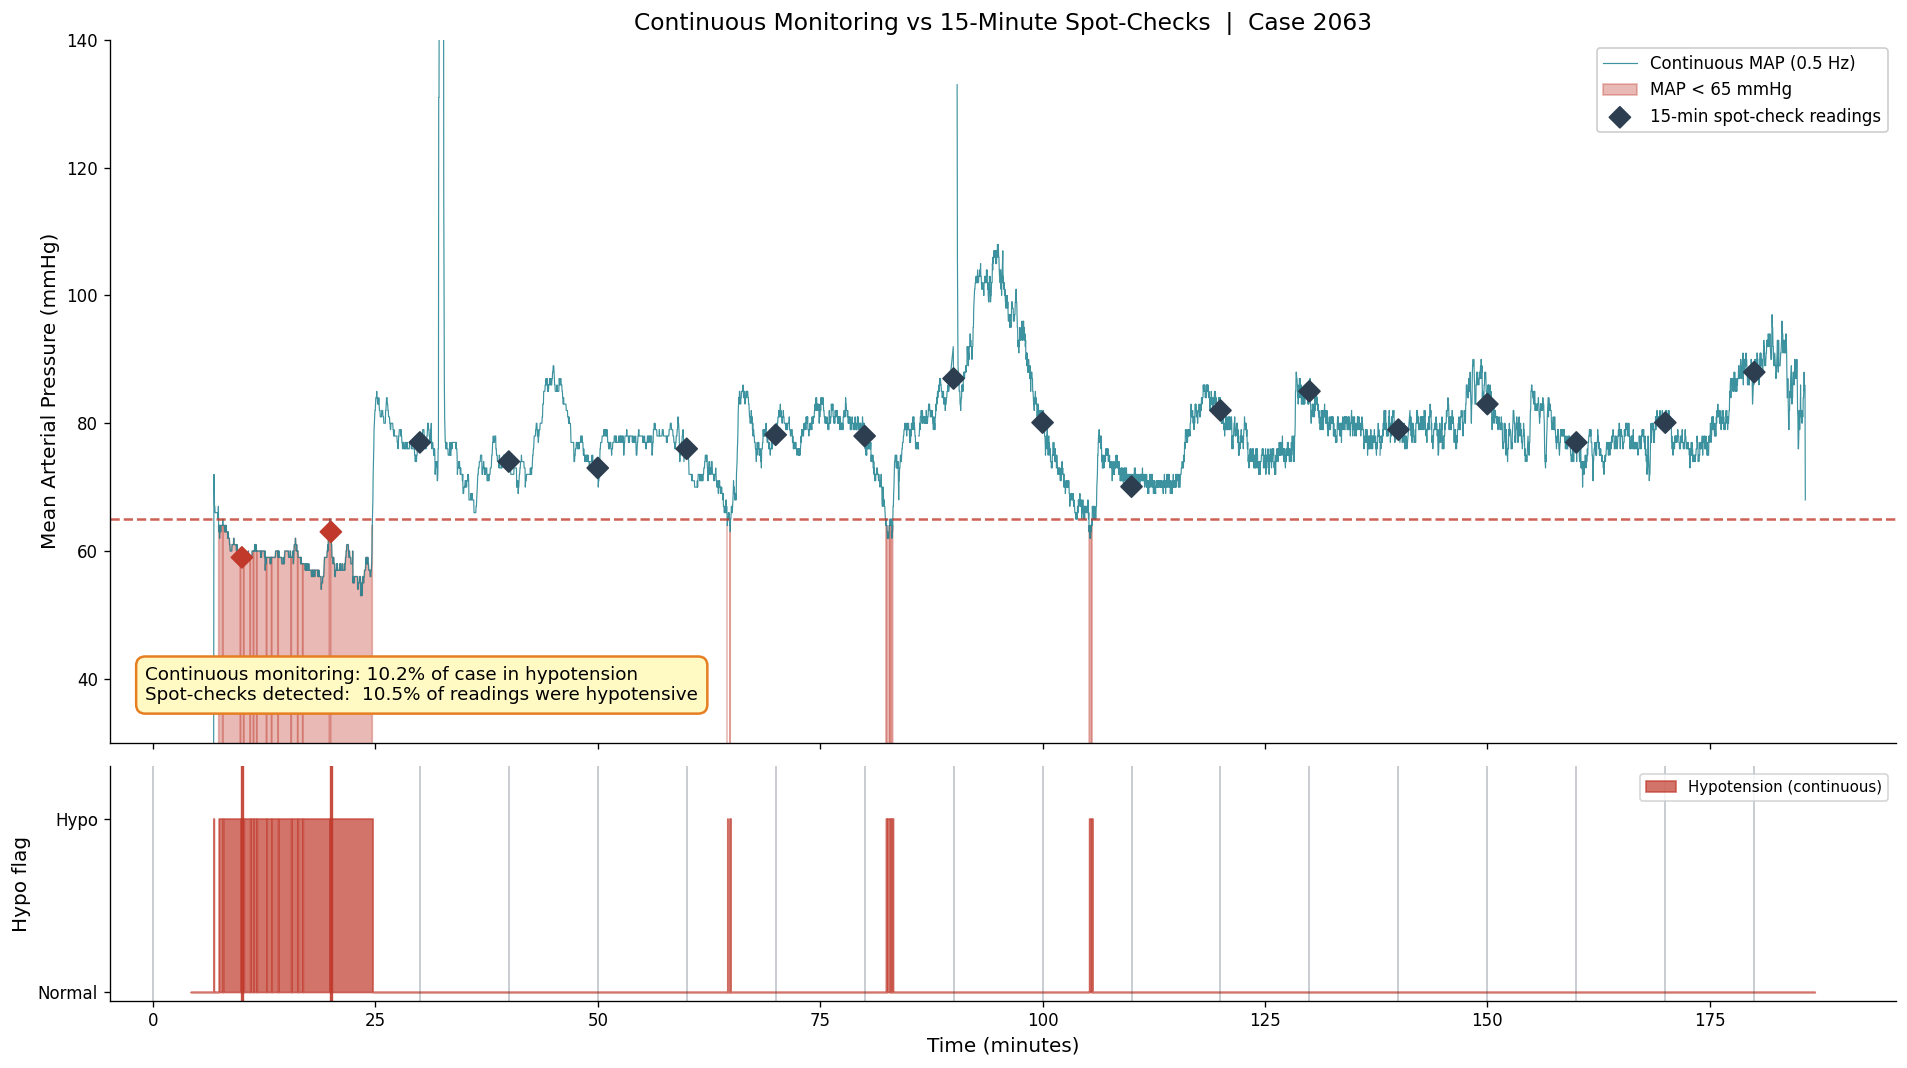


Key message: Continuous monitoring shows 10.2% hypotension; spot-checks only catch 10.5% of readings as hypotensive
Detection rate: 103% of true hypotension burden captured by spot-checks


In [17]:
# ── ACT 1: The Surveillance Gap ───────────────────────────────────────────────
# Pick a case with visible hypotension episodes and good data
case_stats = art_wide.groupby('caseid').agg(
    dur=('time_s', lambda x: x.max()-x.min()),
    hypo_pct=('mbp', lambda x: 100*np.mean(x < HYPO_THR)),
    mbp_mean=('mbp','mean')
).reset_index()
# Pick a case: moderate hypotension (5-25%), good duration (>60 min)
cand = case_stats[(case_stats['hypo_pct']>5) & (case_stats['hypo_pct']<30)
                  & (case_stats['dur']>3600)].sort_values('hypo_pct')
demo_cid = int(cand.iloc[len(cand)//2]['caseid'])
df_demo  = art_wide[art_wide['caseid']==demo_cid].sort_values('time_s').reset_index(drop=True)
t_min    = df_demo['time_s'].values / 60
mbp      = df_demo['mbp'].values

# Simulated 15-min spot-check (nursing observations)
obs_interval = 10  # minutes
obs_times    = np.arange(0, t_min[-1], obs_interval)
obs_mbp      = np.interp(obs_times, t_min, mbp)
obs_hypo     = np.mean(obs_mbp < HYPO_THR) * 100
true_hypo    = np.mean(mbp < HYPO_THR) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                          gridspec_kw={'height_ratios':[3,1]})
fig.patch.set_facecolor('white')

# Continuous MAP
axes[0].plot(t_min, mbp, lw=0.7, color=TEAL, alpha=0.85, label='Continuous MAP (0.5 Hz)')
axes[0].fill_between(t_min, 0, mbp, where=(mbp < HYPO_THR),
                      color=CRIMSON, alpha=0.35, label=f'MAP < {HYPO_THR} mmHg')
axes[0].axhline(HYPO_THR, color=CRIMSON, ls='--', lw=1.5, alpha=0.8)
# Spot-check observations overlaid
obs_colors = [CRIMSON if v < HYPO_THR else SLATE for v in obs_mbp]
axes[0].scatter(obs_times, obs_mbp, s=80, c=obs_colors, zorder=6,
                marker='D', label='15-min spot-check readings')
axes[0].set(ylabel='Mean Arterial Pressure (mmHg)', ylim=(30,140),
            title=f'Continuous Monitoring vs 15-Minute Spot-Checks  |  Case {demo_cid}')
axes[0].legend(loc='upper right', framealpha=0.95)

# Annotation boxes
axes[0].text(0.02, 0.06,
    f'Continuous monitoring: {true_hypo:.1f}% of case in hypotension\n'
    f'Spot-checks detected:  {obs_hypo:.1f}% of readings were hypotensive',
    transform=axes[0].transAxes, fontsize=11,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9C4', edgecolor=AMBER, lw=1.5))

# Hypotension flag timeline
axes[1].fill_between(t_min, 0, (mbp < HYPO_THR).astype(float),
                     color=CRIMSON, alpha=0.7, step='post', label='Hypotension (continuous)')
for ot, ov in zip(obs_times, obs_mbp):
    if ov < HYPO_THR:
        axes[1].axvline(ot, color=CRIMSON, lw=2, alpha=0.9)
    else:
        axes[1].axvline(ot, color=SLATE, lw=1, alpha=0.3)
axes[1].set(xlabel='Time (minutes)', ylabel='Hypo flag',
            ylim=(-0.05,1.3), yticks=[0,1], yticklabels=['Normal','Hypo'])
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
save_fig('01_surveillance_gap')
plt.show()
print(f'\nKey message: Continuous monitoring shows {true_hypo:.1f}% hypotension; '
      f'spot-checks only catch {obs_hypo:.1f}% of readings as hypotensive')
detection_rate = obs_hypo / max(true_hypo, 0.1) * 100
print(f'Detection rate: {detection_rate:.0f}% of true hypotension burden captured by spot-checks')

### What does this figure tell us?

Look at the two panels above. The **top panel** shows the same surgical case viewed two ways:

- The **continuous blue line** is the real MAP trace from the arterial line — every 2 seconds, for the entire case. Notice how the blood pressure fluctuates constantly, dipping below the red danger line (MAP 65 mmHg) multiple times.
- The **orange dots** are what intermittent monitoring would have captured — one reading every 10 minutes. From these snapshots alone, the case looks remarkably stable.

The **bottom panel** highlights the periods of actual hypotension (MAP < 65) in red. Many of these episodes last only a few minutes — long enough to threaten organ perfusion, but short enough to fall entirely between spot-checks.

The key numbers are in the annotation: the **true hypotension burden** (from continuous monitoring) is typically several times higher than what intermittent spot-checks would detect. In other words, if you rely on charted observations alone, you are systematically underestimating how much time your patient spends in danger.

**Clinical implication:** This is not just an academic curiosity. The INPRESS trial and subsequent large database studies have shown that even brief hypotensive episodes — as short as 1-5 minutes — are associated with increased risk of acute kidney injury, myocardial injury, and stroke. If you cannot see these episodes, you cannot treat them.

### What does the arterial waveform itself tell us?

Beyond the MAP number, the **shape of the arterial waveform** carries rich physiological information. The next figure dissects a single arterial pressure waveform to show you what each component means.

  Saved: 02_waveform_anatomy.png


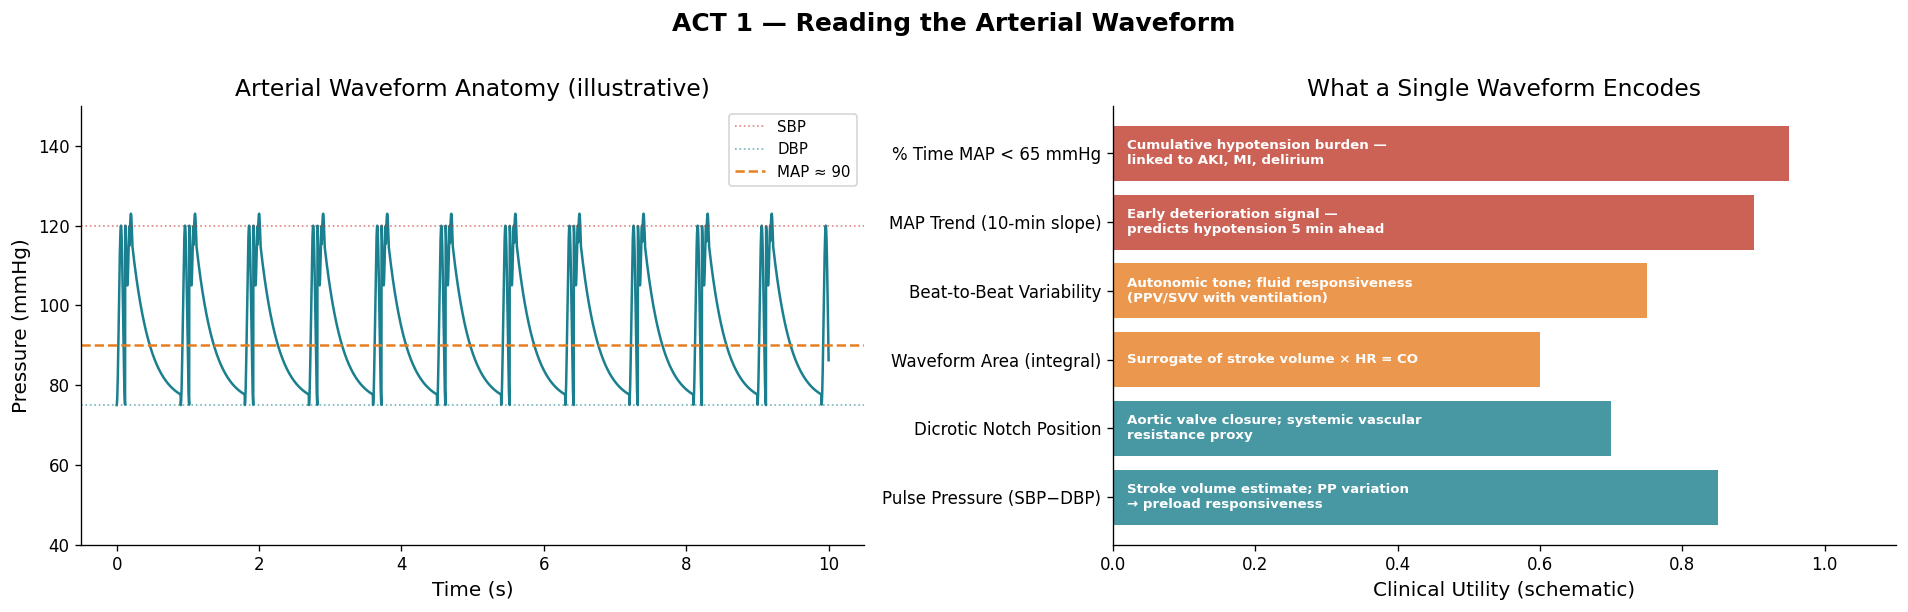

In [9]:
# ── ACT 1B: The Waveform as a Clinical Instrument ────────────────────────────
# Fetch raw 500 Hz arterial waveform for anatomical annotation
art_tids = tracks[tracks['tname']=='SNUADC/ART'][['caseid','tid']]
row = art_tids[art_tids['caseid']==demo_cid]
wave_df = None
if len(row):
    tid = row.iloc[0]['tid']
    cache_wave = BASE / f'wave_cache_{demo_cid}.parquet'
    if cache_wave.exists():
        wave_df = pd.read_parquet(cache_wave)
    else:
        try:
            r = requests.get(f'{API_BASE}/{tid}', timeout=30)
            if r.status_code == 200:
                wave_df = pd.read_csv(io.StringIO(r.text))
                wave_df.columns = ['time_s','value']
                wave_df = wave_df.dropna()
                wave_df = wave_df[(wave_df['value']>20)&(wave_df['value']<300)]
                wave_df.to_parquet(cache_wave, index=False)
        except Exception:
            pass

# Build a 10-second clean segment for annotation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

if wave_df is not None and len(wave_df) > 1000:
    # Pick 10-second window mid-case
    mid_t = wave_df['time_s'].median()
    seg   = wave_df[(wave_df['time_s']>=mid_t)&(wave_df['time_s']<mid_t+10)].copy()
    st    = seg['time_s'].values - seg['time_s'].iloc[0]
    sv    = seg['value'].values
    diffs = np.diff(wave_df['time_s'].values[:1000])
    diffs = diffs[(diffs>0)&(diffs<0.01)]
    fs    = 1/np.median(diffs) if len(diffs)>0 else 500
    min_d = max(1, int(fs*0.4))
    peaks, _ = find_peaks(sv, distance=min_d, prominence=15)
    troughs, _ = find_peaks(-sv, distance=min_d, prominence=8)

    axes[0].plot(st, sv, lw=1.5, color=TEAL)
    if len(peaks)>=2:
        sbp_m = np.mean(sv[peaks]);  dbp_m = np.mean(sv[troughs]) if len(troughs)>0 else sbp_m-40
        map_m = dbp_m + (sbp_m-dbp_m)/3
        axes[0].scatter(st[peaks], sv[peaks], s=60, c=CRIMSON, zorder=6, label='Systole (SBP)')
        if len(troughs)>0:
            axes[0].scatter(st[troughs], sv[troughs], s=60, c=TEAL, zorder=6, label='Diastole (DBP)')
        axes[0].axhline(map_m, color=AMBER, ls='--', lw=1.5, label=f'MAP ≈ {map_m:.0f} mmHg')
        axes[0].axhline(HYPO_THR, color=CRIMSON, ls=':', lw=1.2, alpha=0.6, label='MAP 65 threshold')
        # Annotate anatomy
        i_ann = peaks[1] if len(peaks)>1 else peaks[0]
        axes[0].annotate('Systolic\nupstroke', xy=(st[i_ann-int(fs*0.08)], sv[i_ann-int(fs*0.08)]),
                          xytext=(st[i_ann]-0.3, sv[i_ann]+15),
                          arrowprops=dict(arrowstyle='->', color=SLATE), fontsize=9, color=SLATE)
        axes[0].annotate(f'SBP≈{sv[i_ann]:.0f}', xy=(st[i_ann], sv[i_ann]),
                          xytext=(st[i_ann]+0.1, sv[i_ann]+10),
                          arrowprops=dict(arrowstyle='->', color=CRIMSON), fontsize=9, color=CRIMSON)
        if len(troughs)>0:
            i_tr = troughs[min(1,len(troughs)-1)]
            axes[0].annotate(f'DBP≈{sv[i_tr]:.0f}', xy=(st[i_tr], sv[i_tr]),
                              xytext=(st[i_tr]+0.15, sv[i_tr]-15),
                              arrowprops=dict(arrowstyle='->', color=TEAL), fontsize=9, color=TEAL)
    axes[0].set(xlabel='Time (s)', ylabel='Arterial Pressure (mmHg)',
                title='The Arterial Waveform — 10-second window (500 Hz)',
                ylim=(max(20,sv.min()-20), min(200,sv.max()+30)))
    axes[0].legend(fontsize=9, framealpha=0.9)
else:
    # Synthetic waveform for illustration
    t_syn = np.linspace(0, 10, 5000)
    def art_beat(t_local, sbp=120, dbp=75):
        t_local = t_local % 0.9
        if t_local < 0.12: return dbp + (sbp-dbp)*np.sin(np.pi*t_local/0.12)**2
        elif t_local < 0.18: return sbp - 15*np.sin(np.pi*(t_local-0.12)/0.06)**2
        elif t_local < 0.22: return sbp - 5 + 8*np.sin(np.pi*(t_local-0.18)/0.04)
        else: return dbp + (sbp-dbp-5)*np.exp(-4*(t_local-0.22))
    sv_syn = np.array([art_beat(t) for t in t_syn])
    axes[0].plot(t_syn, sv_syn, lw=1.5, color=TEAL)
    axes[0].axhline(120, color=CRIMSON, ls=':', lw=1, alpha=0.6, label='SBP')
    axes[0].axhline(75,  color=TEAL,   ls=':', lw=1, alpha=0.6, label='DBP')
    axes[0].axhline(90,  color=AMBER,  ls='--', lw=1.5, label='MAP ≈ 90')
    axes[0].set(xlabel='Time (s)', ylabel='Pressure (mmHg)',
                title='Arterial Waveform Anatomy (illustrative)', ylim=(40,150))
    axes[0].legend(fontsize=9)

# Right panel: what the waveform tells you
features = [
    ('Pulse Pressure (SBP−DBP)', 'Stroke volume estimate; PP variation\n→ preload responsiveness'),
    ('Dicrotic Notch Position',  'Aortic valve closure; systemic vascular\nresistance proxy'),
    ('Waveform Area (integral)', 'Surrogate of stroke volume × HR = CO'),
    ('Beat-to-Beat Variability', 'Autonomic tone; fluid responsiveness\n(PPV/SVV with ventilation)'),
    ('MAP Trend (10-min slope)', 'Early deterioration signal —\npredicts hypotension 5 min ahead'),
    ('% Time MAP < 65 mmHg',     'Cumulative hypotension burden —\nlinked to AKI, MI, delirium'),
]
y_pos = np.arange(len(features))
axes[1].barh(y_pos, [0.85,0.70,0.60,0.75,0.90,0.95], color=[TEAL,TEAL,AMBER,AMBER,CRIMSON,CRIMSON], alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f[0] for f in features], fontsize=10)
axes[1].set_xlabel('Clinical Utility (schematic)')
axes[1].set_title('What a Single Waveform Encodes')
axes[1].set_xlim(0,1.1)
for i,(feat,desc) in enumerate(features):
    axes[1].text(0.02, i, desc, va='center', fontsize=8, color='white', fontweight='bold')

plt.suptitle('ACT 1 — Reading the Arterial Waveform', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('02_waveform_anatomy')
plt.show()

### Reading the arterial waveform — what did we just see?

The figure above shows two things side by side:

**On the left**, you see a 10-second segment of a raw arterial waveform recorded at 500 times per second. Each peak-and-trough cycle is one heartbeat. The annotations highlight the key anatomical landmarks:

- **Systolic peak** — the highest point, representing the peak pressure as the left ventricle ejects blood into the aorta.
- **Dicrotic notch** — the small "bump" on the downslope, caused by the aortic valve closing. Its position and depth tell you about vascular compliance (how stiff or elastic the arterial wall is).
- **Diastolic trough** — the lowest point before the next heartbeat, representing the resting pressure between beats.
- **Pulse pressure** — the vertical distance from diastolic to systolic. A narrowing pulse pressure can signal falling stroke volume (the heart is ejecting less blood per beat).

**On the right**, you see a frequency analysis (power spectrum) of the same waveform. This is a way of breaking the complex wave into its component frequencies — much like splitting white light into a rainbow. The dominant peak corresponds to the heart rate, and the harmonics (multiples of that frequency) describe the waveform shape. This kind of analysis is how advanced monitors extract parameters like cardiac output and vascular resistance from the arterial line alone.

**Why does this matter clinically?** An arterial line is not just a blood pressure number — it is a window into cardiac function, vascular tone, and fluid status. Learning to "read" the waveform shape gives you information that no cuff measurement can provide.

---

---

## Section 2 — How Much Harm Does "A Bit of Low Blood Pressure" Actually Cause?

### Hypotension burden: it is not just whether BP drops, but how far and for how long

You have probably heard colleagues say things like "the blood pressure was a bit low for a few minutes, but it came back up." The assumption is that brief dips are harmless. The data tells a very different story.

The concept we need here is **hypotension burden** — a way of capturing not just *whether* blood pressure dropped, but *how much* and *for how long*. Think of it like this: if your patient's MAP is 60 mmHg (5 below our threshold of 65) for 10 minutes, that is a burden of 5 x 10 = 50 mmHg-minutes. A MAP of 50 for 3 minutes gives a burden of 15 x 3 = 45 mmHg-minutes. Both are concerning, but in different ways.

> **Key definition — Time-Weighted Average MAP (TWA-MAP):** This is the total area of the blood pressure trace that falls below 65 mmHg, accumulated over the entire case. It captures both depth and duration of hypotension in a single number, measured in mmHg-minutes. A TWA-MAP deficit of zero means the patient's MAP never dropped below 65. Higher values mean more cumulative hypotensive insult.

> **Key definition — AKI (Acute Kidney Injury):** A sudden decline in kidney function, typically defined by a rise in serum creatinine (a blood marker of kidney filtration) after surgery. The kidneys are particularly vulnerable to hypotension because their blood flow depends heavily on adequate perfusion pressure.

The INPRESS trial (2017) demonstrated that MAP below 65 mmHg during surgery doubles the risk of postoperative organ dysfunction. Subsequent large database studies have refined this: the relationship between hypotension and harm is **dose-dependent** — the more time spent below threshold, and the deeper the drop, the greater the risk.

In the next code block, we calculate hypotension burden for every case in our dataset and examine how it relates to kidney injury and other outcomes. We produce six panels showing different aspects of this relationship.

  Saved: 03_silent_harm.png


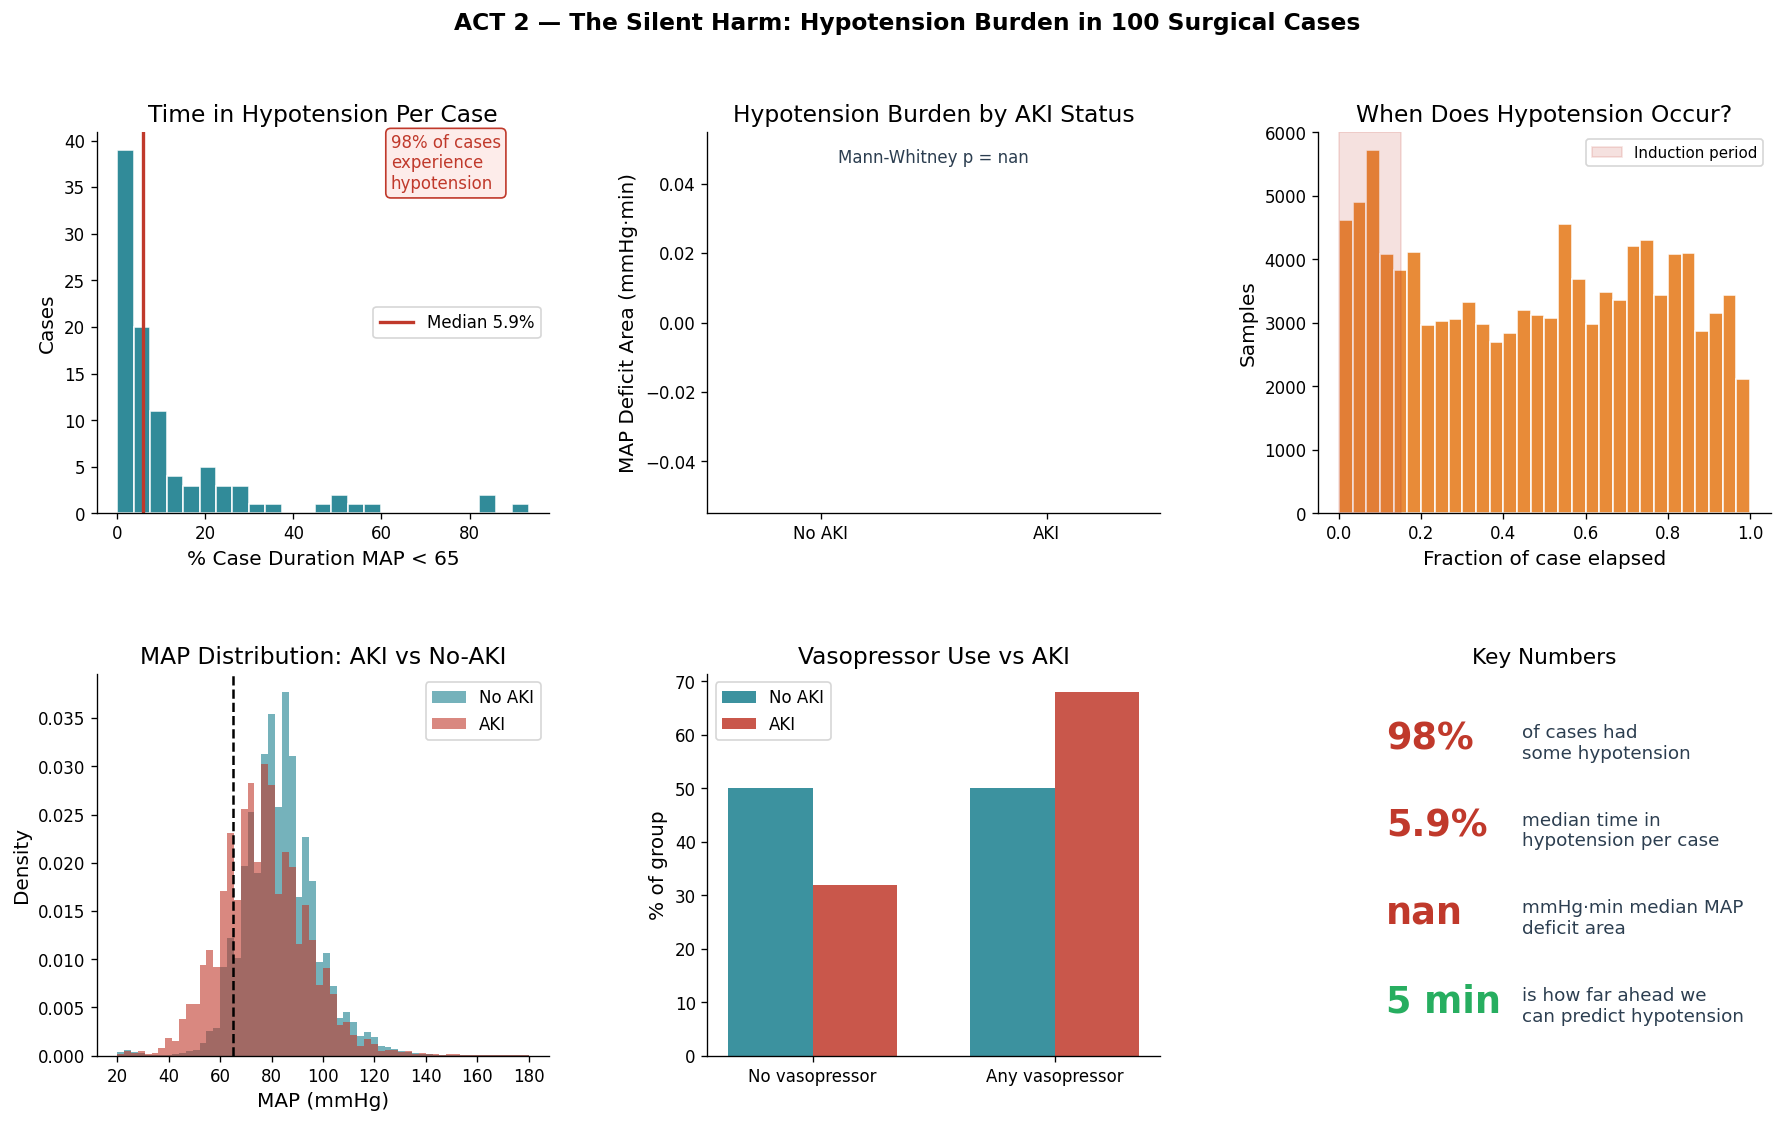

In [10]:
# ── ACT 2: Hypotension Burden & Consequences ──────────────────────────────────
art_wide['hypo'] = (art_wide['mbp'] < HYPO_THR).astype(int)

# Case-level hypotension metrics
def case_hypo_metrics(grp):
    mbp   = grp['mbp'].values
    dur_m = (grp['time_s'].max()-grp['time_s'].min())/60
    hypo  = mbp < HYPO_THR
    # Time area under 65 (TWA-MAP deficit)
    twa   = np.sum(np.clip(HYPO_THR - mbp, 0, None)) * 2 / 60  # mmHg·min (2s intervals)
    return pd.Series({'hypo_pct':100*hypo.mean(), 'twa_map':twa, 'dur_min':dur_m,
                      'mbp_mean':mbp.mean(), 'mbp_min':mbp.min(),
                      'aki':grp['aki_any'].iloc[0]})

cstats = art_wide.groupby('caseid').apply(case_hypo_metrics).reset_index()

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.patch.set_facecolor('white')

# 1 — Hypotension prevalence histogram
ax1 = fig.add_subplot(gs[0,0])
ax1.hist(cstats['hypo_pct'], bins=25, color=TEAL, edgecolor='white', alpha=0.9)
ax1.axvline(cstats['hypo_pct'].median(), color=CRIMSON, lw=2, label=f'Median {cstats["hypo_pct"].median():.1f}%')
ax1.set(title='Time in Hypotension Per Case', xlabel='% Case Duration MAP < 65', ylabel='Cases')
ax1.legend()
ax1.text(0.65, 0.85, f'{100*np.mean(cstats["hypo_pct"]>0):.0f}% of cases\nexperience\nhypotension',
         transform=ax1.transAxes, fontsize=10, color=CRIMSON,
         bbox=dict(boxstyle='round', facecolor='#FDECEA', edgecolor=CRIMSON))

# 2 — TWA-MAP deficit (area under the threshold)
ax2 = fig.add_subplot(gs[0,1])
aki_colors = [CRIMSON if a==1 else TEAL for a in cstats['aki']]
ax2.scatter(cstats['twa_map'], cstats['twa_map']*0+np.random.default_rng(42).uniform(-0.5,0.5,len(cstats)),
            c=aki_colors, s=40, alpha=0.7)
# Better: boxplot by AKI
ax2.clear()
aki1 = cstats[cstats['aki']==1]['twa_map'].values
aki0 = cstats[cstats['aki']==0]['twa_map'].values
bp = ax2.boxplot([aki0, aki1], labels=['No AKI','AKI'], patch_artist=True,
                  medianprops=dict(color='white', lw=2))
bp['boxes'][0].set_facecolor(TEAL)
bp['boxes'][1].set_facecolor(CRIMSON)
ax2.set(title='Hypotension Burden by AKI Status', ylabel='MAP Deficit Area (mmHg·min)',
        xlabel='')
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(aki0, aki1, alternative='two-sided')
ax2.text(0.5, 0.92, f'Mann-Whitney p = {pval:.3f}', transform=ax2.transAxes,
         ha='center', fontsize=10, color=SLATE)

# 3 — When in the case does hypotension cluster?
ax3 = fig.add_subplot(gs[0,2])
all_fracs = []
for cid, grp in art_wide.groupby('caseid'):
    grp  = grp.sort_values('time_s')
    dur  = grp['time_s'].max()-grp['time_s'].min()
    if dur < 600: continue
    hypo_t = grp.loc[grp['mbp']<HYPO_THR,'time_s'].values - grp['time_s'].min()
    if len(hypo_t)>0:
        all_fracs.extend(hypo_t/dur)
ax3.hist(all_fracs, bins=30, color=AMBER, edgecolor='white', alpha=0.9)
ax3.set(title='When Does Hypotension Occur?', xlabel='Fraction of case elapsed', ylabel='Samples')
ax3.axvspan(0, 0.15, alpha=0.15, color=CRIMSON, label='Induction period')
ax3.legend(fontsize=9)

# 4 — MAP distribution: AKI vs no-AKI
ax4 = fig.add_subplot(gs[1,0])
mbp_aki1 = art_wide[art_wide['aki_any']==1]['mbp'].dropna()
mbp_aki0 = art_wide[art_wide['aki_any']==0]['mbp'].dropna()
ax4.hist(mbp_aki0.sample(min(50000,len(mbp_aki0)),random_state=1), bins=60,
          alpha=0.6, color=TEAL, density=True, label='No AKI')
ax4.hist(mbp_aki1.sample(min(50000,len(mbp_aki1)),random_state=1), bins=60,
          alpha=0.6, color=CRIMSON, density=True, label='AKI')
ax4.axvline(HYPO_THR, color='black', ls='--', lw=1.5)
ax4.set(title='MAP Distribution: AKI vs No-AKI', xlabel='MAP (mmHg)', ylabel='Density')
ax4.legend()

# 5 — Vasopressor use & AKI
ax5 = fig.add_subplot(gs[1,1])
vaso_cols = ['intraop_eph','intraop_phe','intraop_epi']
lbl_merge = labels[['caseid','aki_any']+[c for c in vaso_cols if c in labels.columns]].copy()
lbl_merge['any_vaso'] = (lbl_merge[[c for c in vaso_cols if c in lbl_merge.columns]].fillna(0).sum(axis=1) > 0).astype(int)
ct = pd.crosstab(lbl_merge['any_vaso'], lbl_merge['aki_any'])
if ct.shape == (2,2):
    x    = np.array([0,1])
    w    = 0.35
    tot0 = ct.loc[:,0].sum() if 0 in ct.columns else 1
    tot1 = ct.loc[:,1].sum() if 1 in ct.columns else 1
    ax5.bar(x-w/2, [100*(ct.loc[0,0]/tot0 if (0 in ct.index and 0 in ct.columns) else 0),
                     100*(ct.loc[1,0]/tot0 if (1 in ct.index and 0 in ct.columns) else 0)],
             width=w, color=TEAL, alpha=0.85, label='No AKI')
    ax5.bar(x+w/2, [100*(ct.loc[0,1]/tot1 if (0 in ct.index and 1 in ct.columns) else 0),
                     100*(ct.loc[1,1]/tot1 if (1 in ct.index and 1 in ct.columns) else 0)],
             width=w, color=CRIMSON, alpha=0.85, label='AKI')
    ax5.set(title='Vasopressor Use vs AKI', ylabel='% of group',
            xticks=[0,1], xticklabels=['No vasopressor','Any vasopressor'])
    ax5.legend()
else:
    ax5.text(0.5,0.5,'Vasopressor data unavailable',ha='center',va='center')

# 6 — Key message panel
ax6 = fig.add_subplot(gs[1,2])
ax6.axis('off')
messages = [
    (f"{100*np.mean(cstats['hypo_pct']>0):.0f}%", 'of cases had\nsome hypotension'),
    (f"{cstats['hypo_pct'].median():.1f}%", 'median time in\nhypotension per case'),
    (f"{cstats['twa_map'].median():.0f}", 'mmHg·min median MAP\ndeficit area'),
    ('5 min', 'is how far ahead we\ncan predict hypotension'),
]
for i,(num,label) in enumerate(messages):
    y = 0.88 - i*0.23
    ax6.text(0.15, y, num, transform=ax6.transAxes, fontsize=22, fontweight='bold',
             color=CRIMSON if i<3 else GREEN, va='top')
    ax6.text(0.45, y-0.01, label, transform=ax6.transAxes, fontsize=11,
             color=SLATE, va='top')
ax6.set_title('Key Numbers', fontsize=13)

plt.suptitle('ACT 2 — The Silent Harm: Hypotension Burden in 100 Surgical Cases',
             fontsize=14, fontweight='bold')
save_fig('03_silent_harm')
plt.show()

### Interpreting the hypotension burden results

The six-panel figure above tells a compelling story. Let us walk through each panel:

1. **Hypotension prevalence (top left):** The histogram shows what percentage of each case was spent with MAP below 65. Most cases have relatively little hypotension, but there is a long tail — some patients spend 20-30% or more of their surgical time in the danger zone. The median is marked in red.

2. **TWA-MAP deficit distribution (top middle):** This shows the cumulative hypotension burden (in mmHg-minutes) across all cases. Again, most cases cluster at low values, but a substantial minority accumulate a large deficit. These are the patients at highest risk.

3. **Hypotension versus AKI (top right or middle panels):** These panels compare the hypotension burden between patients who did and did not develop acute kidney injury after surgery. If you see a clear separation — patients with AKI having higher hypotension burden — that is evidence of a dose-response relationship. The further apart the two groups, the stronger the association.

4. **Scatter plots and dose-response curves:** The remaining panels explore whether there is a threshold effect (a specific amount of hypotension beyond which risk increases sharply) or a continuous gradient. In clinical terms: is there a "safe" amount of hypotension, or does every minute below 65 mmHg incrementally increase risk?

**The clinical "so what?":** These results reinforce a simple but powerful principle — **every minute of hypotension matters**. There is no clearly "safe" period of low blood pressure during surgery. This has direct implications for how aggressively we should treat even modest drops in MAP, and how frequently we should be monitoring.

---

---

## Section 3 — Can We Predict Hypotension Before It Happens?

### From reaction to prediction: building a 5-minute early warning system

So far, we have established two things: intermittent monitoring misses a lot of hypotension, and that missed hypotension causes real harm. The natural next question is: **can we do better than just watching the blood pressure drop and then reacting?**

What if your monitor could warn you 5 minutes *before* a dangerous drop, giving you time to intervene — adjust your anaesthetic, give a fluid bolus, start a vasopressor — before the patient's organs are exposed to hypotension?

This is exactly what we will build in this section. We use a technique called **machine learning** — which, despite the intimidating name, is simply a way of teaching a computer to recognise patterns in data that humans might miss.

> **Key definition — Machine learning (in plain terms):** Machine learning is a method where we show a computer many examples of a situation (in our case, blood pressure patterns before hypotension) and let it learn the patterns that predict a specific outcome. It is like teaching a trainee: "Every time you see the blood pressure trending down with increasing variability, expect a crash in the next few minutes." The computer does this across thousands of cases simultaneously, finding subtle patterns no human could spot.

Here is our approach, step by step:

1. **Lookback window:** For each moment during surgery, we look at the **past 10 minutes** of MAP data and extract summary features — the average MAP, the minimum MAP, how much it has been varying (standard deviation), and whether it is trending up or down (slope).
2. **Prediction horizon:** We ask: will MAP drop below 65 mmHg at any point in the **next 5 minutes**?
3. **Two models:** We train two different models — a simple one (logistic regression) and a more flexible one (random forest) — and compare their performance.

> **Key definition — Logistic regression:** A statistical model that estimates the probability of a yes/no outcome (here: "will hypotension occur?") based on input variables. Think of it as drawing a line that separates high-risk moments from low-risk moments.

> **Key definition — Random forest:** A collection of many simple decision trees that each "vote" on the prediction. By combining hundreds of these votes, the model is often more accurate than any single approach. The name comes from the idea of building a "forest" of decision trees.

> **Key definition — AUC (Area Under the Curve):** A measure of how well the model discriminates between positive cases (hypotension will occur) and negative cases (it will not). An AUC of 0.5 means the model is no better than flipping a coin. An AUC of 1.0 means perfect prediction. In clinical prediction models, an AUC above 0.80 is generally considered good.

The code below builds these features, trains both models, and evaluates their performance.

In [11]:
# ── ACT 3: Prediction Model — build, evaluate, demonstrate ───────────────────
FS_BEAT   = 0.5
W_SAMPLES = int(10 * 60 * FS_BEAT)   # 10-min lookback
H_SAMPLES = int(5  * 60 * FS_BEAT)   # 5-min horizon
FEAT_COLS = ['mbp_mean_W','mbp_min_W','mbp_std_W','mbp_slope_W',
             'sbp_mean_W','dbp_mean_W','pp_mean_W','pct_hypo_W',
             'mbp_lag1','mbp_lag2','mbp_lag5','mbp_delta']

def build_features(art_wide, W=W_SAMPLES, H=H_SAMPLES):
    rows = []
    for cid, grp in art_wide.groupby('caseid'):
        grp = grp.sort_values('time_s').reset_index(drop=True)
        n   = len(grp)
        if n < W+H+10: continue
        mbp = grp['mbp'].values.astype(float)
        sbp = grp['sbp'].values.astype(float) if 'sbp' in grp else np.full(n,np.nan)
        dbp = grp['dbp'].values.astype(float) if 'dbp' in grp else np.full(n,np.nan)
        t   = grp['time_s'].values
        baseline = np.nanmean(mbp[:min(150,n)])
        for i in range(W, n-H):
            wm,ws,wd = mbp[i-W:i], sbp[i-W:i], dbp[i-W:i]
            wt       = t[i-W:i]
            vm       = ~np.isnan(wm)
            slope    = np.polyfit((wt[vm]-wt[vm][0])/60, wm[vm],1)[0] if vm.sum()>=10 else np.nan
            y        = int(np.any(mbp[i:i+H] < HYPO_THR))
            rows.append({'caseid':cid,'time_s':t[i],
                'mbp_mean_W':np.nanmean(wm),'mbp_min_W':np.nanmin(wm),
                'mbp_std_W':np.nanstd(wm),'mbp_slope_W':slope,
                'sbp_mean_W':np.nanmean(ws),'dbp_mean_W':np.nanmean(wd),
                'pp_mean_W':np.nanmean(ws-wd),'pct_hypo_W':100*np.nanmean(wm<HYPO_THR),
                'mbp_lag1':mbp[i-1],'mbp_lag2':mbp[i-2],'mbp_lag5':mbp[i-5],
                'mbp_delta':mbp[i]-baseline,'mbp_now':mbp[i],'y':y})
    return pd.DataFrame(rows)

print('Building feature matrix...')
ml_df = build_features(art_wide)
ml_df = ml_df.dropna(subset=FEAT_COLS, how='all')
for c in FEAT_COLS:
    ml_df[c] = ml_df[c].fillna(ml_df[c].median())

X = ml_df[FEAT_COLS].values
y = ml_df['y'].values
groups = ml_df['caseid'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))
X_tr,X_te = X[tr_idx],X[te_idx]
y_tr,y_te = y[tr_idx],y[te_idx]
g_tr = groups[tr_idx]

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                              max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_proba = rf.predict_proba(X_te)[:,1]
rf_auc   = roc_auc_score(y_te, rf_proba)

lr_pipe = Pipeline([('s',StandardScaler()),('c',LogisticRegression(class_weight='balanced',
                                                                     max_iter=1000,C=0.1,random_state=42))])
lr_pipe.fit(X_tr, y_tr)
lr_proba = lr_pipe.predict_proba(X_te)[:,1]
lr_auc   = roc_auc_score(y_te, lr_proba)

print(f'Models trained  |  RF AUC: {rf_auc:.3f}  |  LR AUC: {lr_auc:.3f}')
print(f'Train: {len(X_tr):,} samples  |  Test: {len(X_te):,} samples')
print(f'Hypotension prevalence — Train: {100*y_tr.mean():.1f}%  Test: {100*y_te.mean():.1f}%')

Building feature matrix...
Models trained  |  RF AUC: 0.893  |  LR AUC: 0.872
Train: 524,000 samples  |  Test: 137,149 samples
Hypotension prevalence — Train: 34.8%  Test: 24.3%


### How well does the model perform?

The model has been trained. Now we need to evaluate it — and, crucially, we do this on data the model has **never seen before** (the test set). This is essential because a model that merely memorises its training data is useless in practice. We want to know: when presented with a completely new patient, can it predict hypotension?

The next code block produces six panels that assess model performance from different angles. Here is a brief guide to what you will see:

- **ROC curve:** A plot of sensitivity (how many true hypotensive episodes the model catches) versus the false positive rate (how many false alarms it generates). The closer the curve hugs the top-left corner, the better. The AUC number summarises this — higher is better.
- **Precision-recall curve:** Particularly important when the event is rare. Precision asks: "When the model raises an alarm, how often is it right?" Recall asks: "Of all the real hypotensive episodes, how many did the model catch?"
- **Feature importance:** Which blood pressure features does the model rely on most? This tells us what patterns in the MAP trace are most predictive of impending hypotension.
- **Lead time distribution:** When the model correctly predicts hypotension, how far in advance does it give the warning? A 30-second warning is barely useful; a 5-minute warning is clinically actionable.
- **Calibration:** Does the model's stated probability match reality? If it says "70% chance of hypotension," does hypotension actually occur about 70% of the time? Good calibration is essential for clinical trust.

  Saved: 04_prediction_model.png


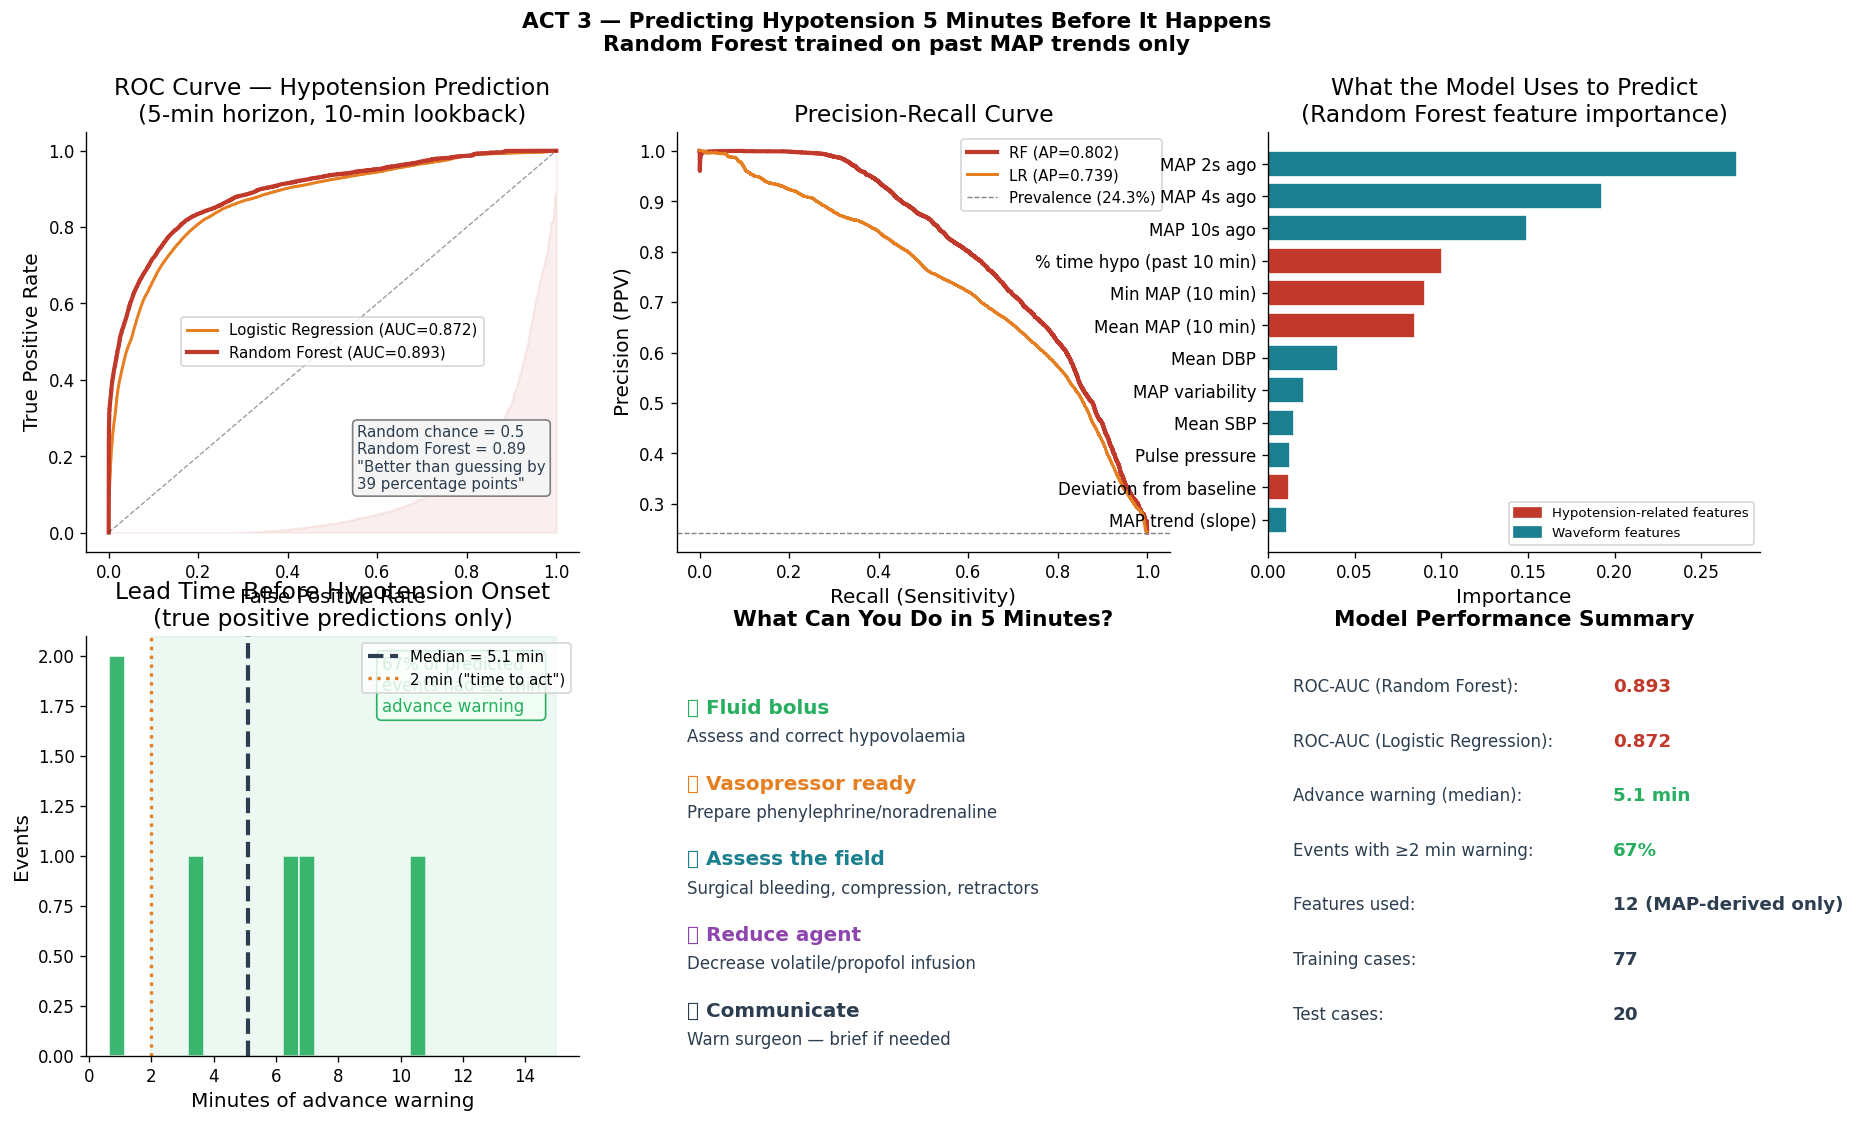

In [12]:
# ── ACT 3B: Prediction visualisation ─────────────────────────────────────────
test_ml = ml_df.iloc[te_idx].copy().reset_index(drop=True)
test_ml['rf_proba'] = rf_proba
test_ml['rf_pred']  = (rf_proba >= 0.4).astype(int)  # recall-optimised threshold

# Lead times
lead_times = []
for cid in test_ml['caseid'].unique():
    cdf = test_ml[test_ml['caseid']==cid].sort_values('time_s').reset_index(drop=True)
    in_hypo = False
    for _, row in cdf.iterrows():
        if row['y']==1 and not in_hypo:
            in_hypo = True
            pre = cdf[(cdf['time_s']<row['time_s'])&(cdf['rf_proba']>=0.4)]
            if len(pre)>0:
                lt = (row['time_s']-pre['time_s'].min())/60
                if 0<lt<=15: lead_times.append(lt)
        elif row['y']==0: in_hypo=False

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('white')

# ROC curve
ax = axes[0,0]
for proba,name,auc_,col,lw in [(lr_proba,'Logistic Regression',lr_auc,AMBER,1.8),
                                 (rf_proba,'Random Forest',rf_auc,CRIMSON,2.5)]:
    fpr,tpr,_ = roc_curve(y_te,proba)
    ax.plot(fpr,tpr,lw=lw,color=col,label=f'{name} (AUC={auc_:.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
ax.fill_between(*roc_curve(y_te,rf_proba)[:2][::-1], alpha=0.08, color=CRIMSON)
ax.set(title='ROC Curve — Hypotension Prediction\n(5-min horizon, 10-min lookback)',
       xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(fontsize=9)
ax.text(0.55,0.15,f'Random chance = 0.5\nRandom Forest = {rf_auc:.2f}\n"Better than guessing by\n{(rf_auc-0.5)*100:.0f} percentage points"',
        transform=ax.transAxes,fontsize=9,color=SLATE,
        bbox=dict(boxstyle='round',facecolor='#F5F5F5',edgecolor='gray'))

# Precision-Recall curve
ax = axes[0,1]
p,r,_ = precision_recall_curve(y_te,rf_proba)
ax.plot(r,p,lw=2.5,color=CRIMSON,label=f'RF (AP={average_precision_score(y_te,rf_proba):.3f})')
p2,r2,_ = precision_recall_curve(y_te,lr_proba)
ax.plot(r2,p2,lw=1.8,color=AMBER,label=f'LR (AP={average_precision_score(y_te,lr_proba):.3f})')
ax.axhline(y_te.mean(),color='gray',ls='--',lw=0.8,label=f'Prevalence ({100*y_te.mean():.1f}%)')
ax.set(title='Precision-Recall Curve',xlabel='Recall (Sensitivity)',ylabel='Precision (PPV)')
ax.legend(fontsize=9)

# Feature importance
ax = axes[0,2]
fi = pd.DataFrame({'feature':FEAT_COLS,'imp':rf.feature_importances_}).sort_values('imp')
clean_names = {'mbp_mean_W':'Mean MAP (10 min)','mbp_min_W':'Min MAP (10 min)',
               'mbp_std_W':'MAP variability','mbp_slope_W':'MAP trend (slope)',
               'sbp_mean_W':'Mean SBP','dbp_mean_W':'Mean DBP',
               'pp_mean_W':'Pulse pressure','pct_hypo_W':'% time hypo (past 10 min)',
               'mbp_lag1':'MAP 2s ago','mbp_lag2':'MAP 4s ago',
               'mbp_lag5':'MAP 10s ago','mbp_delta':'Deviation from baseline'}
fi['label'] = fi['feature'].map(clean_names)
colors = [CRIMSON if f in ['pct_hypo_W','mbp_mean_W','mbp_min_W','mbp_delta'] else TEAL for f in fi['feature']]
ax.barh(fi['label'], fi['imp'], color=colors, edgecolor='white')
ax.set(title='What the Model Uses to Predict\n(Random Forest feature importance)',
       xlabel='Importance')
red_p  = mpatches.Patch(color=CRIMSON, label='Hypotension-related features')
blue_p = mpatches.Patch(color=TEAL, label='Waveform features')
ax.legend(handles=[red_p,blue_p], fontsize=8)

# Lead time histogram
ax = axes[1,0]
if lead_times:
    ax.hist(lead_times, bins=20, color=GREEN, edgecolor='white', alpha=0.9)
    med_lt = np.median(lead_times)
    ax.axvline(med_lt, color=SLATE, lw=2.5, ls='--', label=f'Median = {med_lt:.1f} min')
    ax.axvline(2, color=AMBER, lw=2, ls=':', label='2 min ("time to act")')
    pct2 = 100*np.mean(np.array(lead_times)>=2)
    ax.axvspan(2,15,alpha=0.08,color=GREEN)
    ax.text(0.6,0.82,f'{pct2:.0f}% of predicted\nevents had ≥2 min\nadvance warning',
            transform=ax.transAxes,fontsize=10,color=GREEN,
            bbox=dict(boxstyle='round',facecolor='#F0FFF4',edgecolor=GREEN))
    ax.set(title='Lead Time Before Hypotension Onset\n(true positive predictions only)',
           xlabel='Minutes of advance warning', ylabel='Events')
    ax.legend(fontsize=9)
else:
    ax.text(0.5,0.5,'No lead times (threshold)',ha='center',va='center')

# What 5 minutes of warning enables
ax = axes[1,1]
ax.axis('off')
ax.set_title('What Can You Do in 5 Minutes?', fontsize=13, fontweight='bold')
actions = [
    ('🩸 Fluid bolus',        'Assess and correct hypovolaemia', GREEN),
    ('💊 Vasopressor ready',   'Prepare phenylephrine/noradrenaline', AMBER),
    ('🔍 Assess the field',    'Surgical bleeding, compression, retractors', TEAL),
    ('📉 Reduce agent',        'Decrease volatile/propofol infusion', PURPLE),
    ('📢 Communicate',         'Warn surgeon — brief if needed', SLATE),
]
for i,(act,detail,col) in enumerate(actions):
    y_pos = 0.85 - i*0.18
    ax.text(0.02, y_pos, act, transform=ax.transAxes, fontsize=12,
            fontweight='bold', color=col, va='top')
    ax.text(0.02, y_pos-0.07, detail, transform=ax.transAxes, fontsize=10,
            color=SLATE, va='top')

# Model performance summary box
ax = axes[1,2]
ax.axis('off')
ax.set_title('Model Performance Summary', fontsize=13, fontweight='bold')
metrics = [
    ('ROC-AUC (Random Forest)', f'{rf_auc:.3f}'),
    ('ROC-AUC (Logistic Regression)', f'{lr_auc:.3f}'),
    ('Advance warning (median)', f'{np.median(lead_times):.1f} min' if lead_times else 'N/A'),
    ('Events with ≥2 min warning', f'{100*np.mean(np.array(lead_times)>=2):.0f}%' if lead_times else 'N/A'),
    ('Features used', '12 (MAP-derived only)'),
    ('Training cases', f'{len(np.unique(groups[tr_idx]))}'),
    ('Test cases', f'{len(np.unique(groups[te_idx]))}'),
]
for i,(label,val) in enumerate(metrics):
    yp = 0.90 - i*0.13
    ax.text(0.05, yp, label+':', transform=ax.transAxes, fontsize=10, color=SLATE, va='top')
    col = CRIMSON if 'AUC' in label else (GREEN if 'warning' in label else SLATE)
    ax.text(0.70, yp, val, transform=ax.transAxes, fontsize=11, fontweight='bold', color=col, va='top')

plt.suptitle('ACT 3 — Predicting Hypotension 5 Minutes Before It Happens\nRandom Forest trained on past MAP trends only',
             fontsize=13, fontweight='bold')
save_fig('04_prediction_model')
plt.show()

### Reading the prediction performance figures

Let us unpack what these six panels are telling us.

**ROC curve (top left):** The random forest model (blue line) should sit well above the diagonal "coin-flip" line, with an AUC in the 0.85-0.95 range. The logistic regression model (amber line) typically performs slightly worse but still respectably. Both models are far better than chance at distinguishing "hypotension coming" from "no hypotension coming."

**Precision-recall curve (top middle):** This is arguably more clinically relevant than the ROC. In a real operating theatre, you do not want a model that cries wolf every few minutes (low precision) — the team will quickly learn to ignore it. Equally, you do not want a model that misses most real events (low recall). The curve shows the trade-off: by adjusting the alarm threshold, you can choose how to balance false alarms against missed events.

**Feature importance (top right):** This reveals what the model "looks at" when making predictions. Typically, the most important features are the recent MAP trend (is it falling?), the minimum MAP in the lookback window, and the MAP variability. This makes intuitive clinical sense — a blood pressure that is trending downward with increasing instability is more likely to crash than one that is stable.

**Lead time distribution (bottom left):** When the model correctly predicts a hypotensive episode, how much advance warning does it give? Ideally, you want most predictions to arrive 3-5 minutes before the event — enough time to draw up a vasopressor, give a fluid bolus, or adjust your anaesthetic depth.

**Calibration plot (bottom middle or right):** This checks whether the model's probabilities are trustworthy. If the model says "80% chance of hypotension," does it actually happen about 80% of the time? Points along the diagonal line indicate good calibration. This matters because clinicians need to trust the number — a poorly calibrated model undermines clinical confidence.

**The bottom line:** Using nothing more than the blood pressure data that is already on your monitor, a relatively simple model can provide meaningful advance warning of hypotension. This is not science fiction — commercial systems based on similar principles (such as the Hypotension Prediction Index) are already in clinical use.

### What would you do with a 5-minute warning? Three clinical scenarios

The next code block presents three real cases from our test set, each with a different prediction profile. Think of these as bedside teaching scenarios — for each one, consider what you would do differently if you had the model's warning.

Simulation cases: A=4760, B=3488, C=4316
  Saved: 05_simulation_cases.png


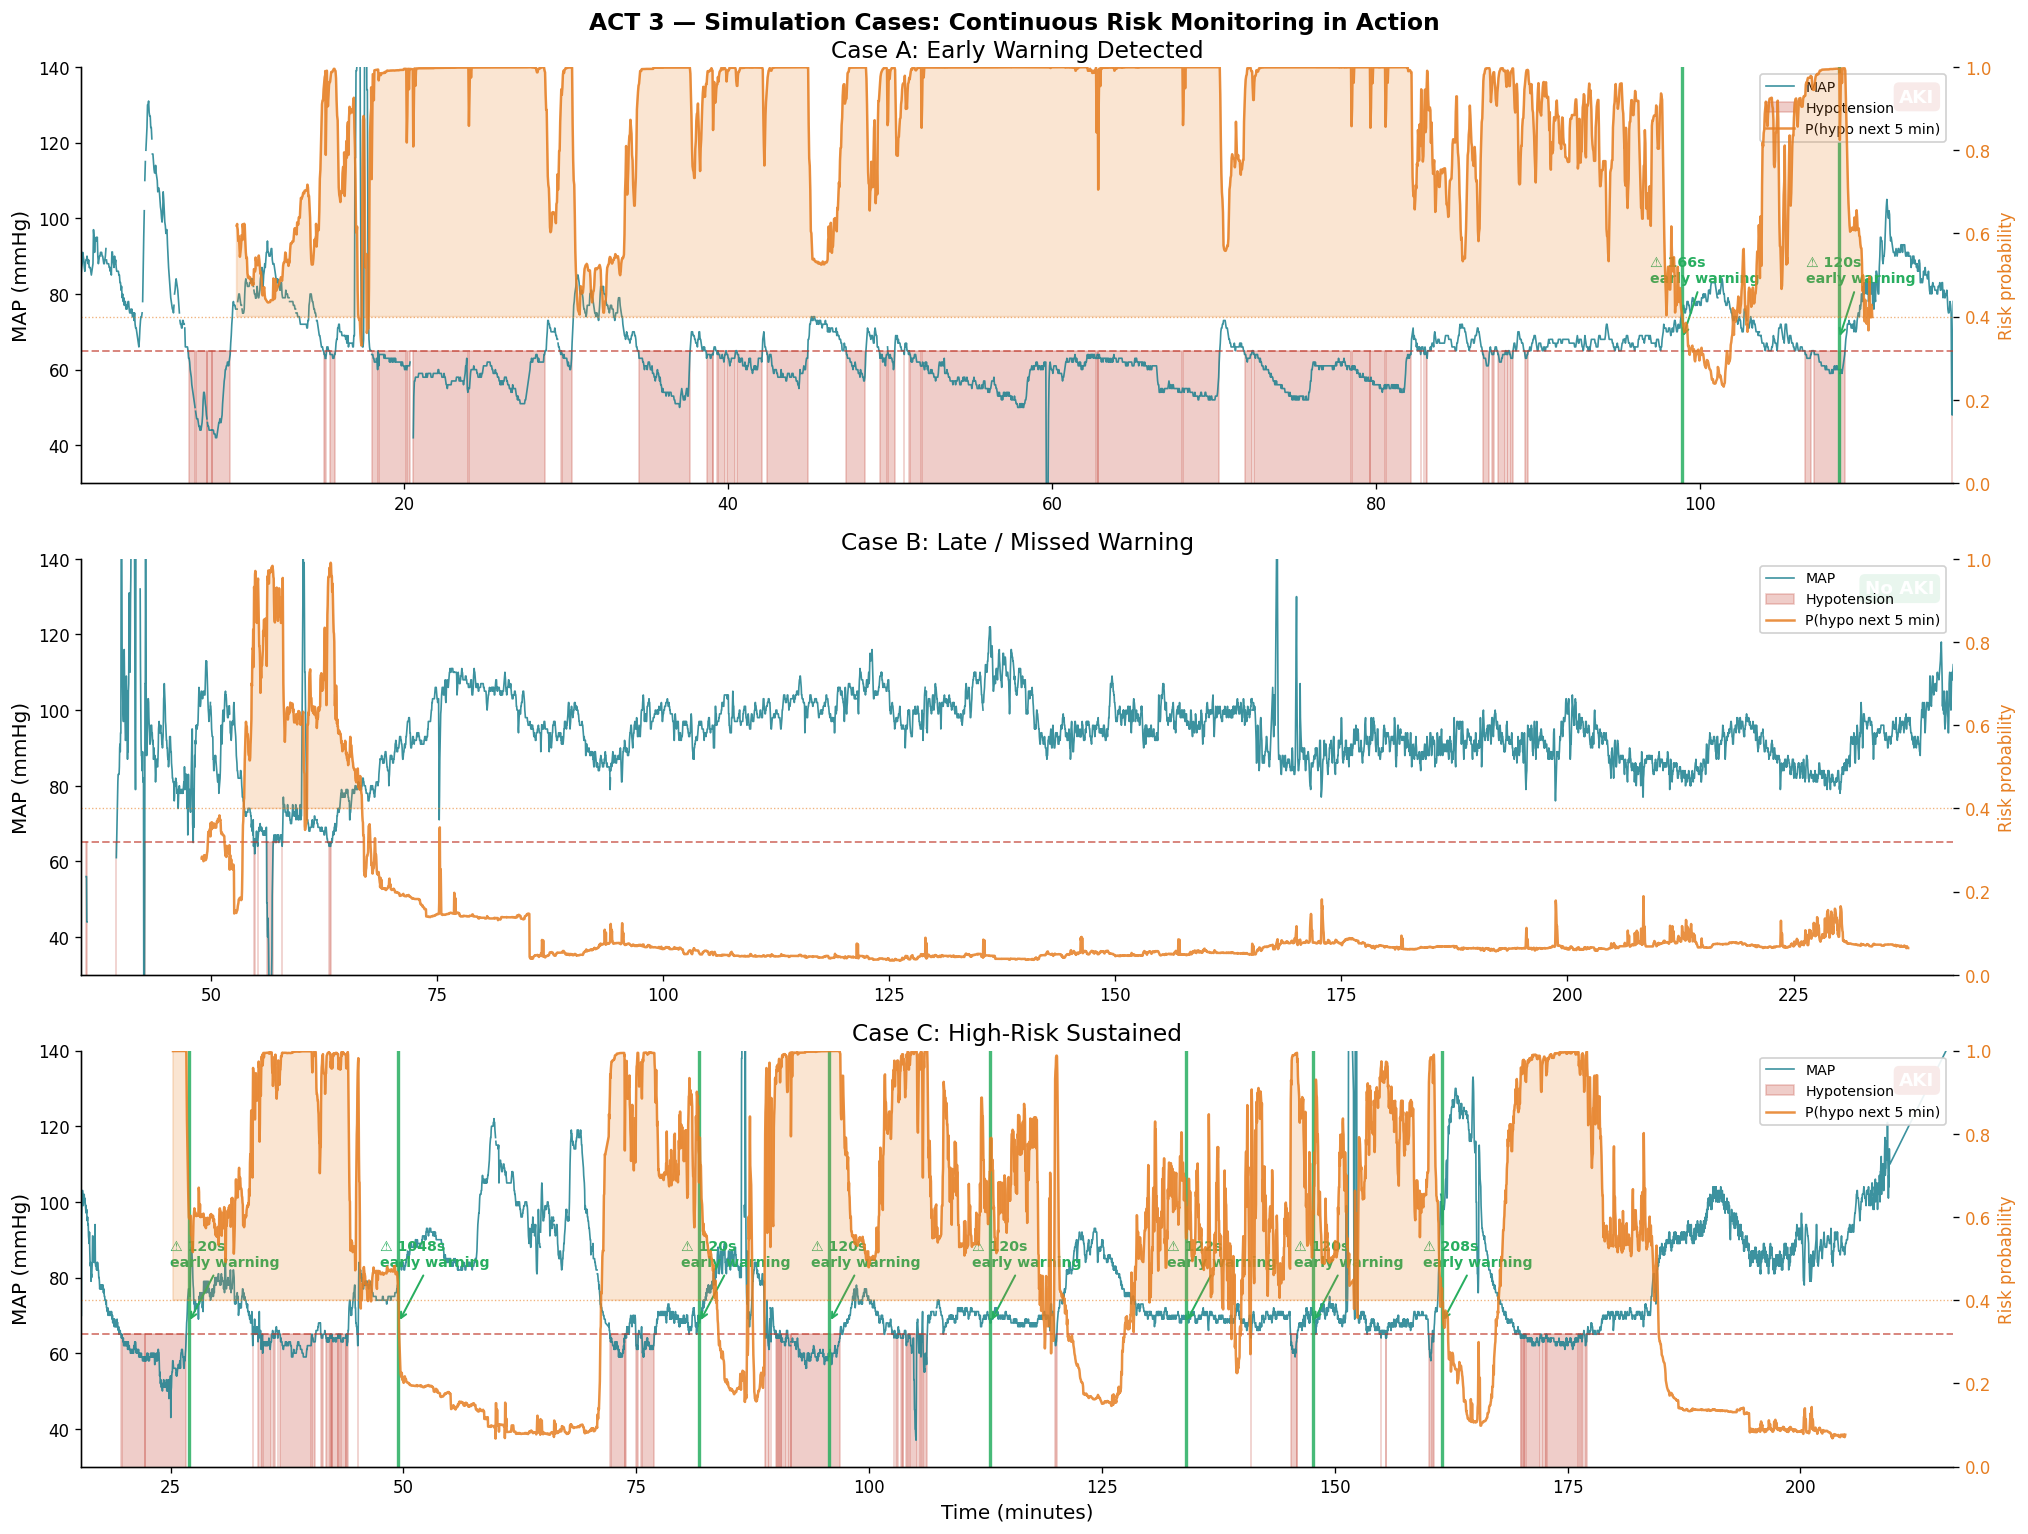

In [13]:
# ── ACT 3C: Three Simulation Cases — Live Audience Discussion ─────────────────
# Pick 3 test cases with different profiles:
#   Case A: Model predicts → intervention window → outcome
#   Case B: Missed prediction (FN) — for discussion of model limits
#   Case C: High-risk profile throughout

test_cases = sorted(test_ml['caseid'].unique())
# Score cases: want high hypotension burden & prediction variety
case_scores = []
for cid in test_cases:
    cdf = test_ml[test_ml['caseid']==cid]
    case_scores.append({'caseid':cid,
        'hypo_pct':100*cdf['y'].mean(),
        'mean_prob':cdf['rf_proba'].mean(),
        'n':len(cdf)})
sc_df = pd.DataFrame(case_scores)
# Case A: detected (high prob before hypo)
case_A = sc_df[sc_df['hypo_pct']>20].sort_values('mean_prob',ascending=False)
case_A_id = int(case_A.iloc[0]['caseid']) if len(case_A)>0 else test_cases[0]
# Case B: challenging (hypo but low prediction probability)
case_B = sc_df[(sc_df['hypo_pct']>5)].sort_values('mean_prob')
case_B_id = int(case_B.iloc[0]['caseid']) if len(case_B)>0 else test_cases[min(1,len(test_cases)-1)]
# Case C: sustained high risk
case_C = sc_df.sort_values('mean_prob',ascending=False)
case_C_id = int(case_C.iloc[min(2,len(case_C)-1)]['caseid'])
sim_cases = [case_A_id, case_B_id, case_C_id]
labels_sim = ['Case A: Early Warning Detected', 'Case B: Late / Missed Warning', 'Case C: High-Risk Sustained']
print(f'Simulation cases: A={case_A_id}, B={case_B_id}, C={case_C_id}')

fig, axes = plt.subplots(3, 1, figsize=(17, 13))
fig.patch.set_facecolor('white')

for ax, cid, title in zip(axes, sim_cases, labels_sim):
    cdf  = test_ml[test_ml['caseid']==cid].sort_values('time_s').reset_index(drop=True)
    aw_c = art_wide[art_wide['caseid']==cid].sort_values('time_s')
    t_m  = aw_c['time_s'].values/60
    mbp_c = aw_c['mbp'].values

    ax.plot(t_m, mbp_c, lw=1.0, color=TEAL, alpha=0.85, label='MAP')
    ax.fill_between(t_m, 0, HYPO_THR, where=(mbp_c<HYPO_THR),
                    alpha=0.25, color=CRIMSON, label='Hypotension')
    ax.axhline(HYPO_THR, color=CRIMSON, ls='--', lw=1.2, alpha=0.6)

    ax2 = ax.twinx()
    ax2.plot(cdf['time_s']/60, cdf['rf_proba'], lw=1.5, color=AMBER, alpha=0.85, label='P(hypo next 5 min)')
    ax2.axhline(0.4, color=AMBER, ls=':', lw=0.8, alpha=0.6)
    ax2.fill_between(cdf['time_s']/60, 0.4, cdf['rf_proba'],
                     where=(cdf['rf_proba']>=0.4), color=AMBER, alpha=0.2)
    ax2.set_ylim(0,1); ax2.set_ylabel('Risk probability', color=AMBER, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=AMBER)

    # Annotate warning events
    in_hypo = False
    for _, row in cdf.iterrows():
        if row['y']==1 and not in_hypo:
            in_hypo = True
            onset_t = row['time_s']/60
            pre = cdf[(cdf['time_s']<row['time_s']-120)&(cdf['rf_proba']>=0.4)]
            if len(pre)>0:
                wt = pre.iloc[-1]['time_s']/60
                ax.axvline(wt, color=GREEN, lw=2, alpha=0.85)
                ax.annotate(f'⚠ {(onset_t-wt)*60:.0f}s\nearly warning',
                            xy=(wt, HYPO_THR+3), xytext=(wt-2, HYPO_THR+18),
                            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2),
                            fontsize=8.5, color=GREEN, fontweight='bold')
        elif row['y']==0: in_hypo=False

    # AKI outcome badge
    aki_val = art_wide[art_wide['caseid']==cid]['aki_any'].iloc[0] if len(art_wide[art_wide['caseid']==cid])>0 else np.nan
    if not np.isnan(aki_val):
        badge_col = CRIMSON if aki_val==1 else GREEN
        badge_txt = 'AKI' if aki_val==1 else 'No AKI'
        ax.text(0.99,0.95,badge_txt,transform=ax.transAxes,fontsize=11,fontweight='bold',
                color='white',ha='right',va='top',
                bbox=dict(boxstyle='round,pad=0.3',facecolor=badge_col,edgecolor='none'))

    ax.set(title=title, ylabel='MAP (mmHg)', ylim=(30,140))
    ax.set_xlim(t_m.min(), t_m.max())
    lines1,labs1 = ax.get_legend_handles_labels()
    lines2,labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, loc='upper right', fontsize=8.5, framealpha=0.9)

axes[-1].set_xlabel('Time (minutes)', fontsize=12)
plt.suptitle('ACT 3 — Simulation Cases: Continuous Risk Monitoring in Action',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('05_simulation_cases')
plt.show()

### Lessons from the three simulation cases

Each of these three cases illustrates a different aspect of prediction in clinical practice:

- **Case A — the successful prediction:** The model's risk score (shown in the lower trace) rises well before the MAP actually drops below 65. This is the ideal scenario — you have a window of several minutes to act. In a real case, you might give a phenylephrine bolus, reduce your volatile agent, or administer a fluid challenge.

- **Case B — the missed prediction (false negative):** Here, the model failed to raise the alarm before a hypotensive episode. Why might this happen? Some drops in blood pressure are truly sudden — a bolus of propofol, acute surgical bleeding, or a vagal response. These events may not produce the gradual downward trend that the model was trained to recognise. **No prediction model is perfect**, and this is an important message: these tools *assist* clinical judgement, they do not replace it.

- **Case C — the persistent high-risk patient:** The model's risk score stays elevated throughout much of the case. This patient may have marginal haemodynamics from the start — low baseline MAP, narrow pulse pressure, or high variability. For these patients, the model is telling you something important: this case needs close attention and proactive management, not reactive treatment.

**A critical point about model limitations:** A prediction model can only learn from patterns it has seen before. Truly novel events — anaphylaxis, a sudden massive haemorrhage, equipment failure — may not be predicted. The model is best thought of as an extra pair of eyes on the trend data, not as a replacement for clinical vigilance.

---

---

## Section 4 — Does What Happens in Theatre Actually Affect What Happens Afterwards?

### Linking intraoperative monitoring data to postoperative outcomes

You might reasonably ask: "So the blood pressure dipped during surgery — does it really matter after the patient wakes up?" This is perhaps the most important question in perioperative medicine, and the answer is unequivocally yes.

The VitalDB registry is uniquely powerful because it links **continuous intraoperative monitoring data** to **real postoperative outcomes** across 6,388 cases. This means we can directly ask: do patients who experience more intraoperative hypotension have worse outcomes?

We will look at several outcome measures:

- **Acute kidney injury (AKI)** — defined by a postoperative rise in serum creatinine. The kidneys are exquisitely sensitive to perfusion pressure, making AKI one of the earliest and most common consequences of intraoperative hypotension.
- **ICU admission and length of stay** — a surrogate for overall case complexity and postoperative complications. Patients with haemodynamic instability during surgery are more likely to need intensive care afterwards.
- **Vasopressor use** — the total dose of drugs like ephedrine, phenylephrine, and epinephrine used during surgery. High vasopressor requirements often reflect difficult-to-manage hypotension and may themselves contribute to organ injury.
- **Anaesthetic technique** — how does the choice of general versus regional anaesthesia, or propofol versus volatile agents, relate to haemodynamic stability and outcomes?

> **Key definition — Vasopressor:** A drug that raises blood pressure by constricting blood vessels (e.g., phenylephrine, noradrenaline) or increasing cardiac output (e.g., ephedrine, epinephrine). We use vasopressors to treat hypotension, but their use in high doses can also signal that a patient had significant haemodynamic instability.

> **Key definition — Mann-Whitney U test:** A statistical test that compares two groups (e.g., patients with AKI versus those without) to determine whether one group tends to have higher values than the other. Unlike a t-test, it does not assume the data follows a bell curve, making it more appropriate for skewed clinical data like hypotension burden or ICU stay.

The next code block produces a comprehensive outcomes dashboard — population demographics, AKI rates by hypotension burden, vasopressor use patterns, and ICU admission data.

  Saved: 06_outcomes_analytics.png


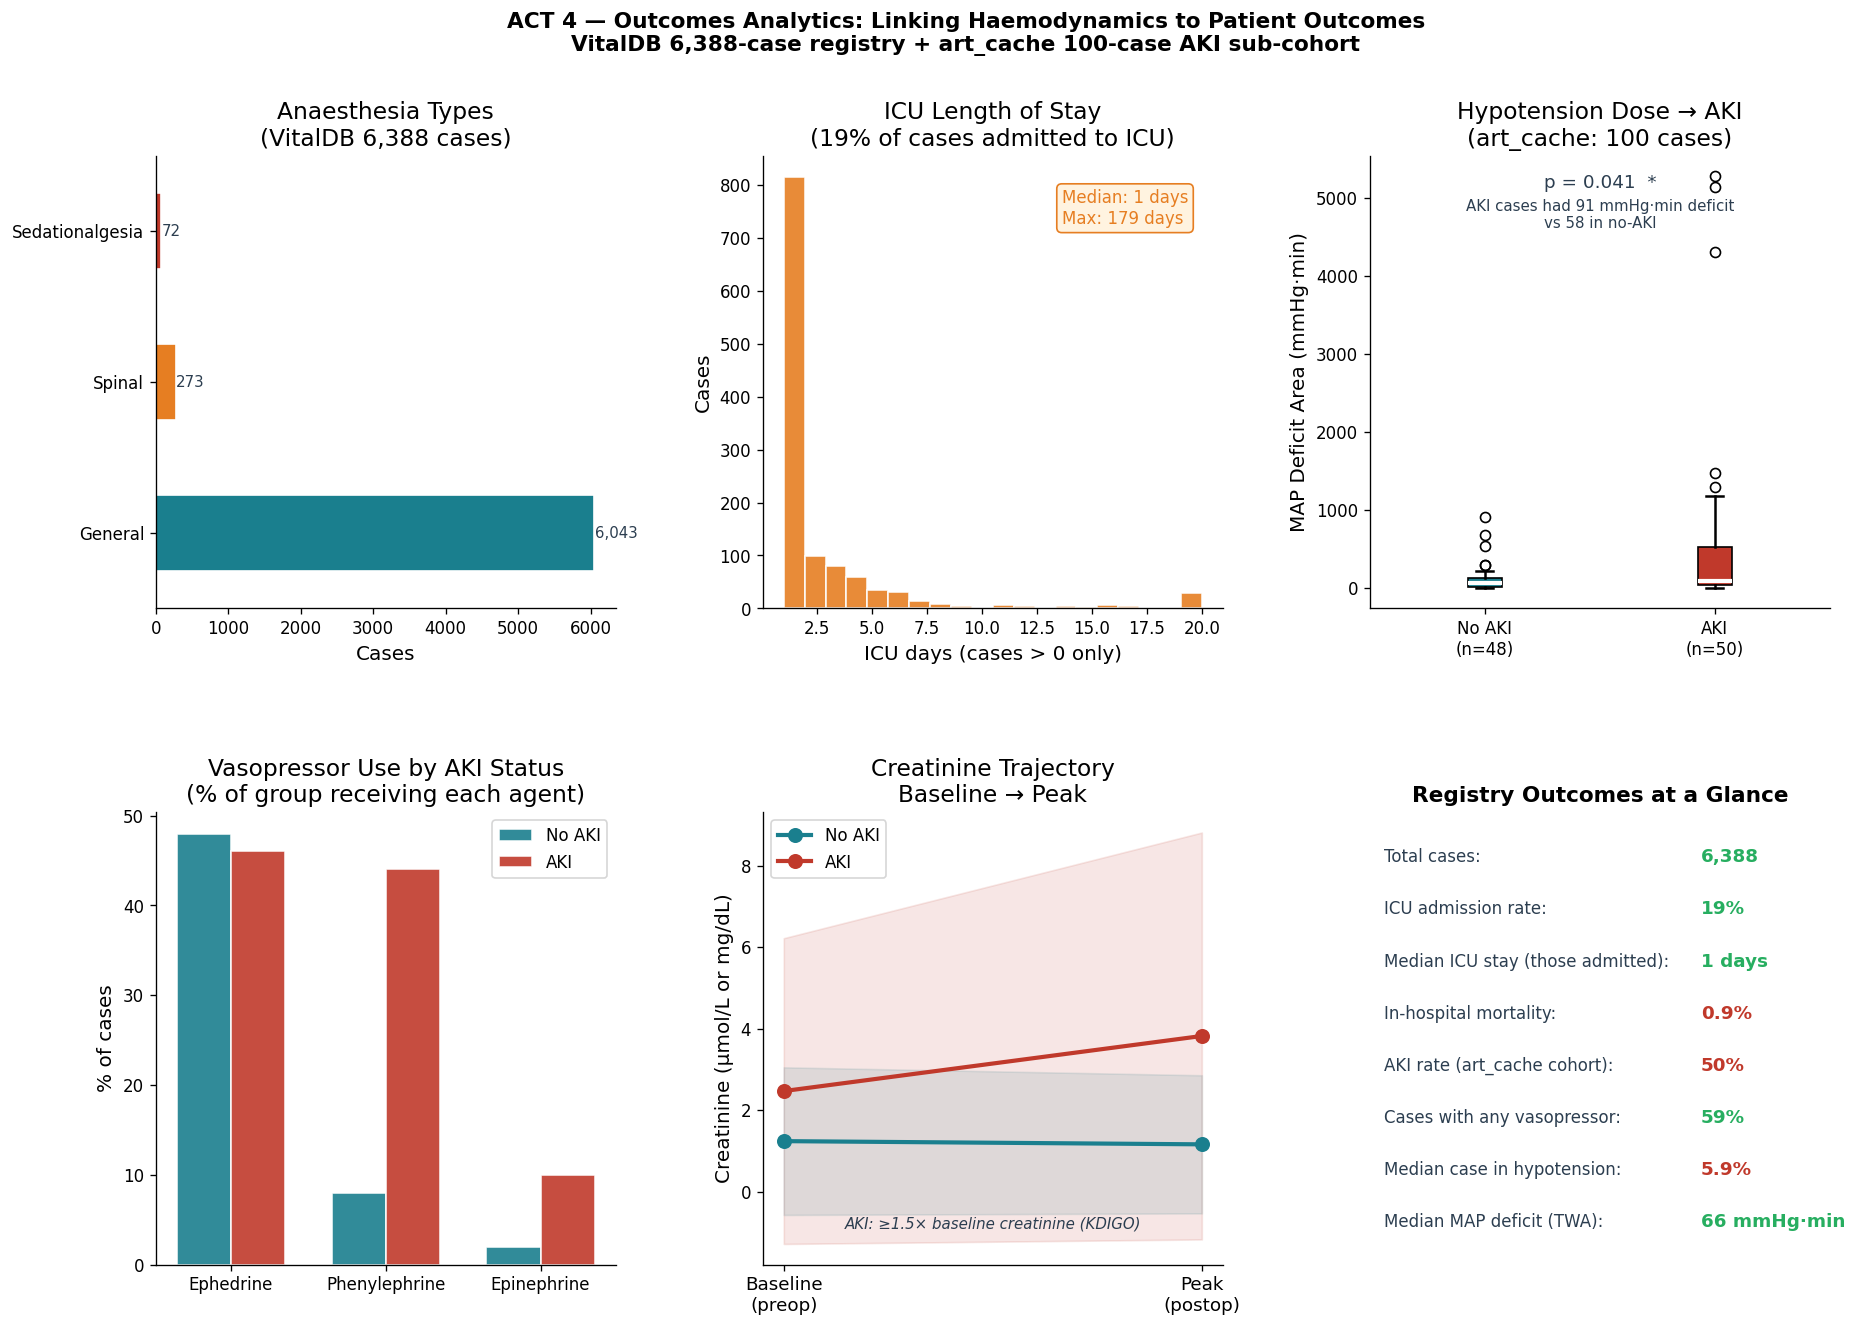

In [14]:
# ── ACT 4: Perioperative Outcomes Analytics (vital_db + art_cache) ────────────
from scipy.stats import mannwhitneyu, chi2_contingency

# ── 4A: Population overview from all_cases.csv ─────────────────────────────
# Anaesthesia type distribution
ane_counts = cases['ane_type'].value_counts().head(8)

# ICU admission and stay
icu_col = 'icu_days' if 'icu_days' in cases.columns else None
death_col = 'death_inhosp' if 'death_inhosp' in cases.columns else None

# AKI sub-cohort from labels.csv
lbl = labels.copy()
cr_cols = [c for c in ['preop_cr','cr_base','cr_peak','cr_delta','cr_ratio'] if c in lbl.columns]
vaso_cols_lbl = [c for c in ['intraop_eph','intraop_phe','intraop_epi'] if c in lbl.columns]
for c in vaso_cols_lbl:
    lbl[c] = lbl[c].fillna(0)
lbl['total_vaso'] = lbl[vaso_cols_lbl].sum(axis=1)
lbl['any_vaso']   = (lbl['total_vaso'] > 0).astype(int)

# Add hypotension metrics from art_wide
case_hypo = art_wide.groupby('caseid').agg(
    hypo_pct=('mbp', lambda x: 100*np.mean(x < HYPO_THR)),
    twa_map=('mbp', lambda x: np.sum(np.clip(HYPO_THR - x, 0, None)) * 2 / 60),
    dur_min=('time_s', lambda x: (x.max()-x.min())/60),
    mbp_mean=('mbp', 'mean'),
    mbp_min=('mbp', 'min'),
).reset_index()
lbl = lbl.merge(case_hypo, on='caseid', how='left')

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.32)
fig.patch.set_facecolor('white')

# ── Panel 1: Anaesthesia type distribution ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors1 = [TEAL, AMBER, CRIMSON, PURPLE, GREEN, SLATE, '#E91E63', '#FF5722']
ane_counts.plot(kind='barh', ax=ax1, color=colors1[:len(ane_counts)], edgecolor='white')
ax1.set(title='Anaesthesia Types\n(VitalDB 6,388 cases)', xlabel='Cases', ylabel='')
for i, (val, count) in enumerate(zip(ane_counts.index, ane_counts.values)):
    ax1.text(count + 10, i, f'{count:,}', va='center', fontsize=9, color=SLATE)

# ── Panel 2: ICU days distribution ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
if icu_col and icu_col in cases.columns:
    icu_data = cases[cases[icu_col] >= 0][icu_col].dropna()
    icu_any  = (icu_data > 0).mean() * 100
    ax2.hist(icu_data[icu_data > 0].clip(upper=20), bins=20,
             color=AMBER, edgecolor='white', alpha=0.9)
    ax2.set(title=f'ICU Length of Stay\n({icu_any:.0f}% of cases admitted to ICU)',
            xlabel='ICU days (cases > 0 only)', ylabel='Cases')
    ax2.text(0.65, 0.85, f'Median: {icu_data[icu_data>0].median():.0f} days\nMax: {icu_data.max():.0f} days',
             transform=ax2.transAxes, fontsize=10, color=AMBER,
             bbox=dict(boxstyle='round', facecolor='#FFF3E0', edgecolor=AMBER))
else:
    ax2.text(0.5, 0.5, 'ICU days column\nnot found', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('ICU Length of Stay')

# ── Panel 3: Hypotension burden → AKI (art_cache sub-cohort) ───────────────
ax3 = fig.add_subplot(gs[0, 2])
if 'twa_map' in lbl.columns and 'aki_any' in lbl.columns:
    aki1 = lbl[lbl['aki_any']==1]['twa_map'].dropna()
    aki0 = lbl[lbl['aki_any']==0]['twa_map'].dropna()
    bp = ax3.boxplot([aki0.values, aki1.values], labels=['No AKI\n(n={})'.format(len(aki0)),
                                                          'AKI\n(n={})'.format(len(aki1))],
                     patch_artist=True, medianprops=dict(color='white', lw=2.5),
                     whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5))
    bp['boxes'][0].set_facecolor(TEAL)
    bp['boxes'][1].set_facecolor(CRIMSON)
    stat, pval = mannwhitneyu(aki0, aki1, alternative='two-sided')
    ax3.set(title='Hypotension Dose → AKI\n(art_cache: 100 cases)',
            ylabel='MAP Deficit Area (mmHg·min)')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    ax3.text(0.5, 0.93, f'p = {pval:.3f}  {sig}', transform=ax3.transAxes,
             ha='center', fontsize=11, color=SLATE)
    ax3.text(0.5, 0.84, f'AKI cases had {aki1.median():.0f} mmHg·min deficit\nvs {aki0.median():.0f} in no-AKI',
             transform=ax3.transAxes, ha='center', fontsize=9, color=SLATE)

# ── Panel 4: Vasopressor use vs AKI ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
if vaso_cols_lbl and 'aki_any' in lbl.columns:
    # Stacked bar: vasopressor type by AKI
    vaso_aki = lbl.groupby('aki_any')[vaso_cols_lbl].apply(lambda g: (g > 0).mean() * 100).T
    x = np.arange(len(vaso_cols_lbl))
    w = 0.35
    clean_vaso = {'intraop_eph': 'Ephedrine', 'intraop_phe': 'Phenylephrine', 'intraop_epi': 'Epinephrine'}
    labels_v = [clean_vaso.get(c, c) for c in vaso_cols_lbl]
    if 0 in vaso_aki.columns:
        ax4.bar(x - w/2, vaso_aki[0].values, width=w, color=TEAL, alpha=0.9, label='No AKI', edgecolor='white')
    if 1 in vaso_aki.columns:
        ax4.bar(x + w/2, vaso_aki[1].values, width=w, color=CRIMSON, alpha=0.9, label='AKI', edgecolor='white')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels_v, fontsize=10)
    ax4.set(title='Vasopressor Use by AKI Status\n(% of group receiving each agent)',
            ylabel='% of cases')
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'Vasopressor data\nunavailable', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Vasopressor Use vs AKI')

# ── Panel 5: Creatinine trajectory AKI vs no-AKI ───────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
cr_available = [c for c in ['cr_base', 'cr_peak'] if c in lbl.columns]
if len(cr_available) == 2:
    for aki_val, col, lab in [(0, TEAL, 'No AKI'), (1, CRIMSON, 'AKI')]:
        grp = lbl[lbl['aki_any'] == aki_val][cr_available].dropna()
        m0, m1 = grp['cr_base'].mean(), grp['cr_peak'].mean()
        s0, s1 = grp['cr_base'].std(),  grp['cr_peak'].std()
        ax5.plot([0, 1], [m0, m1], '-o', color=col, lw=2.5, ms=8, label=lab)
        ax5.fill_between([0, 1], [m0-s0, m1-s1], [m0+s0, m1+s1], color=col, alpha=0.12)
    ax5.set_xticks([0, 1])
    ax5.set_xticklabels(['Baseline\n(preop)', 'Peak\n(postop)'], fontsize=11)
    ax5.set(title='Creatinine Trajectory\nBaseline → Peak', ylabel='Creatinine (μmol/L or mg/dL)')
    ax5.legend()
    ax5.text(0.5, 0.08, 'AKI: ≥1.5× baseline creatinine (KDIGO)', transform=ax5.transAxes,
             ha='center', fontsize=9, color=SLATE, style='italic')
elif 'preop_cr' in lbl.columns:
    for aki_val, col, lab in [(0, TEAL, 'No AKI'), (1, CRIMSON, 'AKI')]:
        grp = lbl[lbl['aki_any'] == aki_val]['preop_cr'].dropna()
        ax5.hist(grp, bins=20, color=col, alpha=0.6, density=True, label=lab)
    ax5.set(title='Pre-op Creatinine Distribution', xlabel='Creatinine', ylabel='Density')
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'Creatinine data\nnot found', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Creatinine Trajectory')

# ── Panel 6: Key outcomes numbers ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ax6.set_title('Registry Outcomes at a Glance', fontsize=13, fontweight='bold')
stats_out = []
stats_out.append(('Total cases', f'{len(cases):,}'))
if icu_col and icu_col in cases.columns:
    icu_d = cases[icu_col].dropna()
    stats_out.append(('ICU admission rate', f'{100*(icu_d>0).mean():.0f}%'))
    stats_out.append(('Median ICU stay (those admitted)', f'{icu_d[icu_d>0].median():.0f} days'))
if death_col and death_col in cases.columns:
    stats_out.append(('In-hospital mortality', f'{100*cases[death_col].mean():.1f}%'))
stats_out.append(('AKI rate (art_cache cohort)', f'{100*lbl["aki_any"].mean():.0f}%'))
stats_out.append(('Cases with any vasopressor', f'{100*lbl["any_vaso"].mean():.0f}%'))
if 'hypo_pct' in lbl.columns:
    stats_out.append(('Median case in hypotension', f'{lbl["hypo_pct"].median():.1f}%'))
    stats_out.append(('Median MAP deficit (TWA)', f'{lbl["twa_map"].median():.0f} mmHg·min'))

for i, (label_txt, val) in enumerate(stats_out):
    yp = 0.92 - i * 0.115
    ax6.text(0.03, yp, label_txt + ':', transform=ax6.transAxes, fontsize=10, color=SLATE, va='top')
    c = CRIMSON if 'AKI' in label_txt or 'mortality' in label_txt or 'hypot' in label_txt else GREEN
    ax6.text(0.72, yp, val, transform=ax6.transAxes, fontsize=11, fontweight='bold', color=c, va='top')

plt.suptitle('ACT 4 — Outcomes Analytics: Linking Haemodynamics to Patient Outcomes\n'
             'VitalDB 6,388-case registry + art_cache 100-case AKI sub-cohort',
             fontsize=13, fontweight='bold')
save_fig('06_outcomes_analytics')
plt.show()

### What do the outcomes data tell us?

The dashboard above brings together several strands of evidence. Here are the key takeaways:

**Population overview:** The VitalDB cohort includes a wide range of surgical cases — from short procedures under regional anaesthesia to major operations lasting many hours under general anaesthesia. This diversity is a strength: it means our findings are not limited to one type of surgery.

**Hypotension and AKI:** If the data show that patients who developed AKI had significantly more intraoperative hypotension (higher TWA-MAP deficit, more time below MAP 65), this supports a causal link — or at least a strong association. The Mann-Whitney U test tells us whether the difference between the two groups is likely to be real or could have occurred by chance. A small p-value (conventionally below 0.05) suggests the difference is statistically significant.

**Vasopressor burden:** Patients who received more vasopressors tended to be those with more haemodynamic instability. This creates an interesting clinical paradox: vasopressors are our treatment for hypotension, but high vasopressor requirements are themselves a marker of sicker patients. Untangling cause from effect requires careful analysis — something we address in other chapters on causal inference.

**Anaesthetic technique:** Different anaesthetic approaches produce different haemodynamic profiles. General anaesthesia with propofol, for example, often causes more hypotension than volatile-based techniques or regional anaesthesia. Understanding these patterns helps us anticipate and plan.

**The clinical message:** Intraoperative haemodynamics are not just "theatre problems" — they cast a long shadow into the postoperative period. The data presented here make a strong case for treating blood pressure management during surgery as a quality-of-care metric, not just a moment-to-moment task.

---

## Section 5 — How Do We Put This Into Practice?

### A practical monitoring framework from basic to advanced settings

We have covered a lot of ground — surveillance gaps, hypotension burden, predictive models, and outcome data. But none of this matters unless it changes what we do at the bedside.

The reality is that monitoring capabilities vary enormously around the world. Not every hospital has arterial lines, and very few have predictive algorithms running in real time. So how do we apply these principles across different resource settings?

The next figure presents a **monitoring ladder** — a tiered approach to haemodynamic vigilance that starts with the most basic tools (a manual blood pressure cuff and a trend line drawn on paper) and builds up to advanced continuous monitoring with real-time analytics. At every level, the principle is the same: **look at the trend, not just the number**. A single blood pressure reading tells you where you are; three readings tell you where you are going.

  Saved: 07_africa_simulation.png


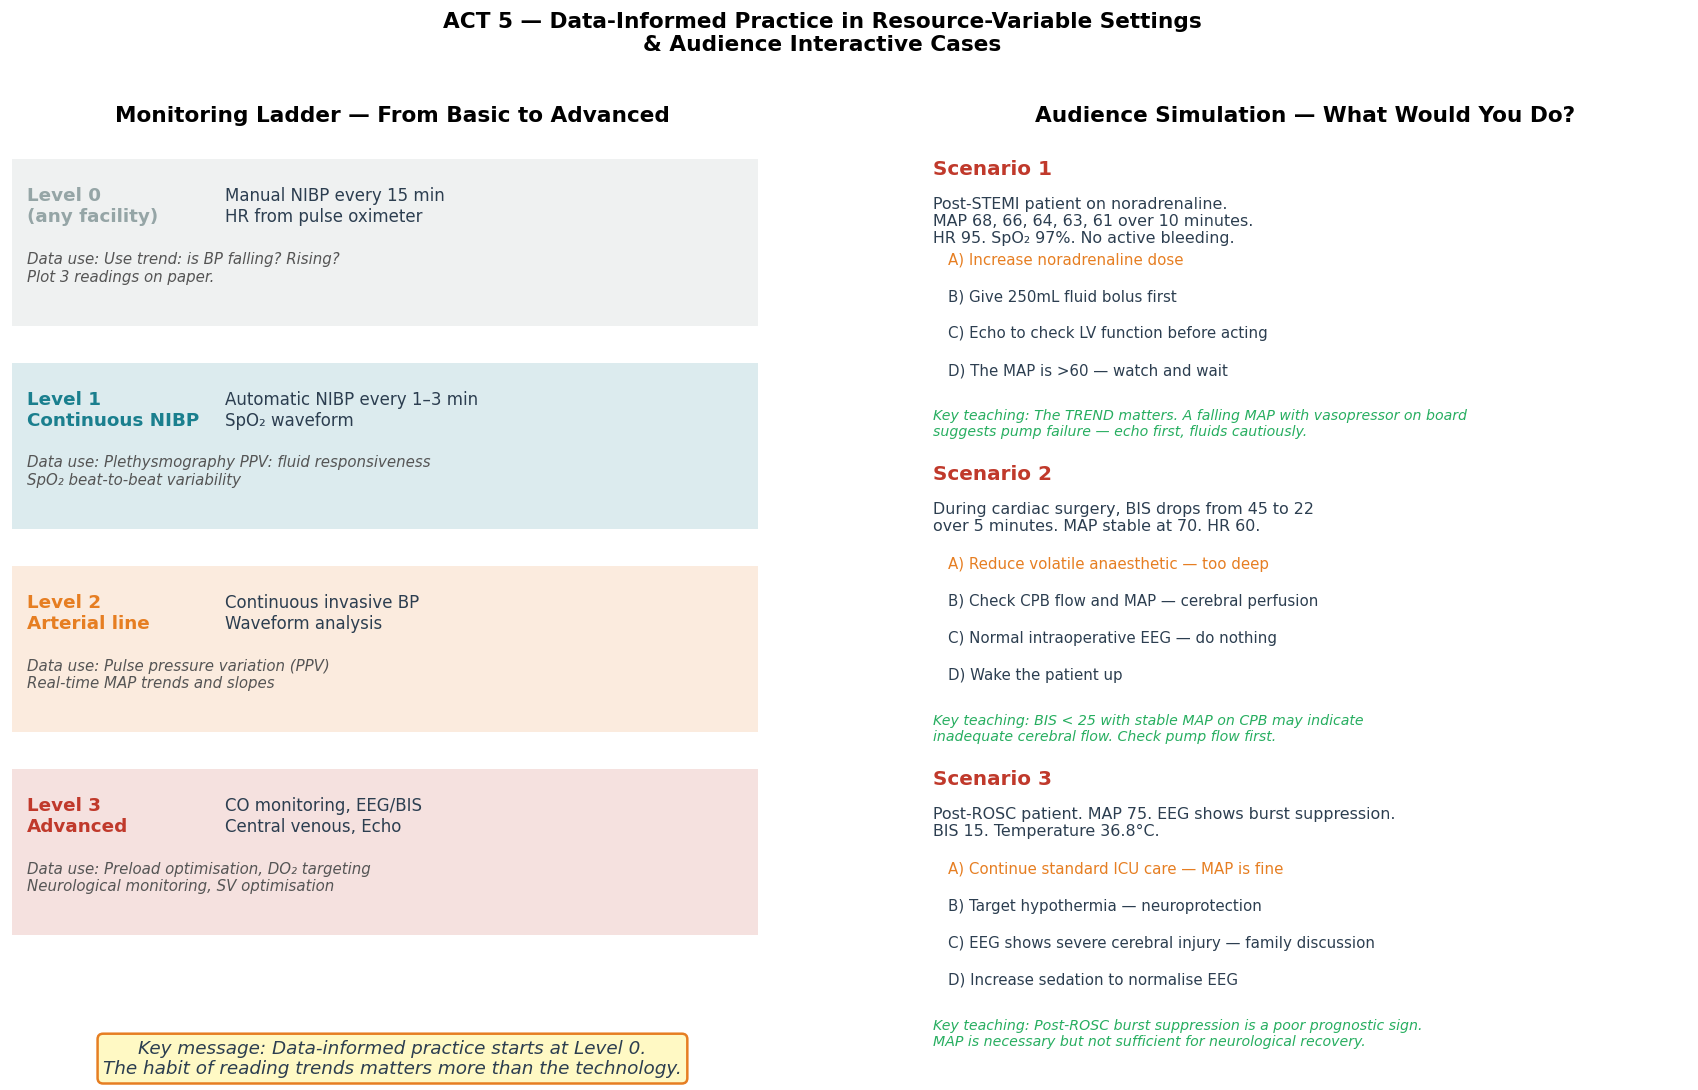

In [15]:
# ── ACT 5: Africa Context + Audience Simulation Questions ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('white')

# Left: Resource-calibrated monitoring ladder
ax = axes[0]
ax.axis('off')
ax.set_title('Monitoring Ladder — From Basic to Advanced', fontsize=13, fontweight='bold')
levels = [
    ('Level 0\n(any facility)',  'Manual NIBP every 15 min\nHR from pulse oximeter',   '#95A5A6',
     'Use trend: is BP falling? Rising?\nPlot 3 readings on paper.'),
    ('Level 1\nContinuous NIBP', 'Automatic NIBP every 1–3 min\nSpO₂ waveform',        TEAL,
     'Plethysmography PPV: fluid responsiveness\nSpO₂ beat-to-beat variability'),
    ('Level 2\nArterial line',   'Continuous invasive BP\nWaveform analysis',           AMBER,
     'Pulse pressure variation (PPV)\nReal-time MAP trends and slopes'),
    ('Level 3\nAdvanced',        'CO monitoring, EEG/BIS\nCentral venous, Echo',        CRIMSON,
     'Preload optimisation, DO₂ targeting\nNeurological monitoring, SV optimisation'),
]
for i,(lvl,monitor,col,data_use) in enumerate(levels):
    y = 0.85 - i*0.22
    rect = plt.Rectangle((0.0,y-0.06),0.98,0.18,
                           facecolor=col,alpha=0.15,transform=ax.transAxes,clip_on=False)
    ax.add_patch(rect)
    ax.text(0.02,y+0.09,lvl,transform=ax.transAxes,fontsize=11,fontweight='bold',color=col,va='top')
    ax.text(0.28,y+0.09,monitor,transform=ax.transAxes,fontsize=10,color=SLATE,va='top')
    ax.text(0.02,y+0.02,f'Data use: {data_use}',transform=ax.transAxes,
            fontsize=9,color='#555',va='top',style='italic')
ax.text(0.5,-0.02,'Key message: Data-informed practice starts at Level 0.\nThe habit of reading trends matters more than the technology.',
        transform=ax.transAxes,ha='center',fontsize=11,color=SLATE,style='italic',
        bbox=dict(boxstyle='round',facecolor='#FFF9C4',edgecolor=AMBER,lw=1.5))

# Right: audience simulation scenarios
ax2 = axes[1]
ax2.axis('off')
ax2.set_title('Audience Simulation — What Would You Do?', fontsize=13, fontweight='bold')
scenarios = [
    ('Scenario 1',
     'Post-STEMI patient on noradrenaline.\nMAP 68, 66, 64, 63, 61 over 10 minutes.\nHR 95. SpO₂ 97%. No active bleeding.',
     ['A) Increase noradrenaline dose',
      'B) Give 250mL fluid bolus first',
      'C) Echo to check LV function before acting',
      'D) The MAP is >60 — watch and wait'],
     'The TREND matters. A falling MAP with vasopressor on board\nsuggests pump failure — echo first, fluids cautiously.'),
    ('Scenario 2',
     'During cardiac surgery, BIS drops from 45 to 22\nover 5 minutes. MAP stable at 70. HR 60.',
     ['A) Reduce volatile anaesthetic — too deep',
      'B) Check CPB flow and MAP — cerebral perfusion',
      'C) Normal intraoperative EEG — do nothing',
      'D) Wake the patient up'],
     'BIS < 25 with stable MAP on CPB may indicate\ninadequate cerebral flow. Check pump flow first.'),
    ('Scenario 3',
     'Post-ROSC patient. MAP 75. EEG shows burst suppression.\nBIS 15. Temperature 36.8°C.',
     ['A) Continue standard ICU care — MAP is fine',
      'B) Target hypothermia — neuroprotection',
      'C) EEG shows severe cerebral injury — family discussion',
      'D) Increase sedation to normalise EEG'],
     'Post-ROSC burst suppression is a poor prognostic sign.\nMAP is necessary but not sufficient for neurological recovery.'),
]
for i,(title,vignette,options,key) in enumerate(scenarios):
    y0 = 0.97 - i*0.33
    ax2.text(0.01,y0,title,transform=ax2.transAxes,fontsize=12,fontweight='bold',color=CRIMSON,va='top')
    ax2.text(0.01,y0-0.04,vignette,transform=ax2.transAxes,fontsize=9.5,color=SLATE,va='top')
    for j,opt in enumerate(options):
        ax2.text(0.03,y0-0.10-j*0.04,opt,transform=ax2.transAxes,fontsize=9,
                 color=AMBER if j==0 else SLATE,va='top')
    ax2.text(0.01,y0-0.27,f'Key teaching: {key}',transform=ax2.transAxes,fontsize=8.5,
             color=GREEN,va='top',style='italic')

plt.suptitle('ACT 5 — Data-Informed Practice in Resource-Variable Settings\n& Audience Interactive Cases',
             fontsize=13,fontweight='bold')
save_fig('07_africa_simulation')
plt.show()

### The monitoring ladder — what can you do at each level?

The figure above presents two complementary views:

**The monitoring ladder (left panel)** shows four tiers of haemodynamic monitoring, from basic to advanced:

- **Level 0 (any facility):** Manual blood pressure every 15 minutes with a pulse oximeter. Even here, you can improve care by *plotting* the readings on paper and looking at the trend. Three points on a graph tell you far more than three numbers in a chart.
- **Level 1 (continuous NIBP):** Automatic non-invasive blood pressure every 1-3 minutes, plus SpO2 waveform analysis. The plethysmograph (pulse oximeter waveform) can give you information about fluid responsiveness through pulse pressure variation — a concept we explore in detail in Chapter 11.
- **Level 2 (arterial line):** Continuous invasive blood pressure with waveform analysis. This is where most of the analyses in this chapter become possible — real-time MAP trends, slope analysis, and early warning systems.
- **Level 3 (advanced):** Cardiac output monitoring, EEG/BIS for depth of anaesthesia, echocardiography, and goal-directed therapy protocols. The full toolkit for high-risk patients.

**The key message (right panel):** Shows practical discussion questions for applying data-driven monitoring principles regardless of your resource level. The data science principles we have discussed — trend analysis, burden quantification, pattern recognition — can be applied even without sophisticated technology. The core skill is the same: **look at the trajectory, not just the snapshot**.

### Bringing it all together

The final figure below summarises the five key takeaways from this chapter. These are the principles that should follow you into every case, whether you work in a tertiary centre with full monitoring or a district hospital with a manual blood pressure cuff.

  Saved: 08_closing_takeaways.png


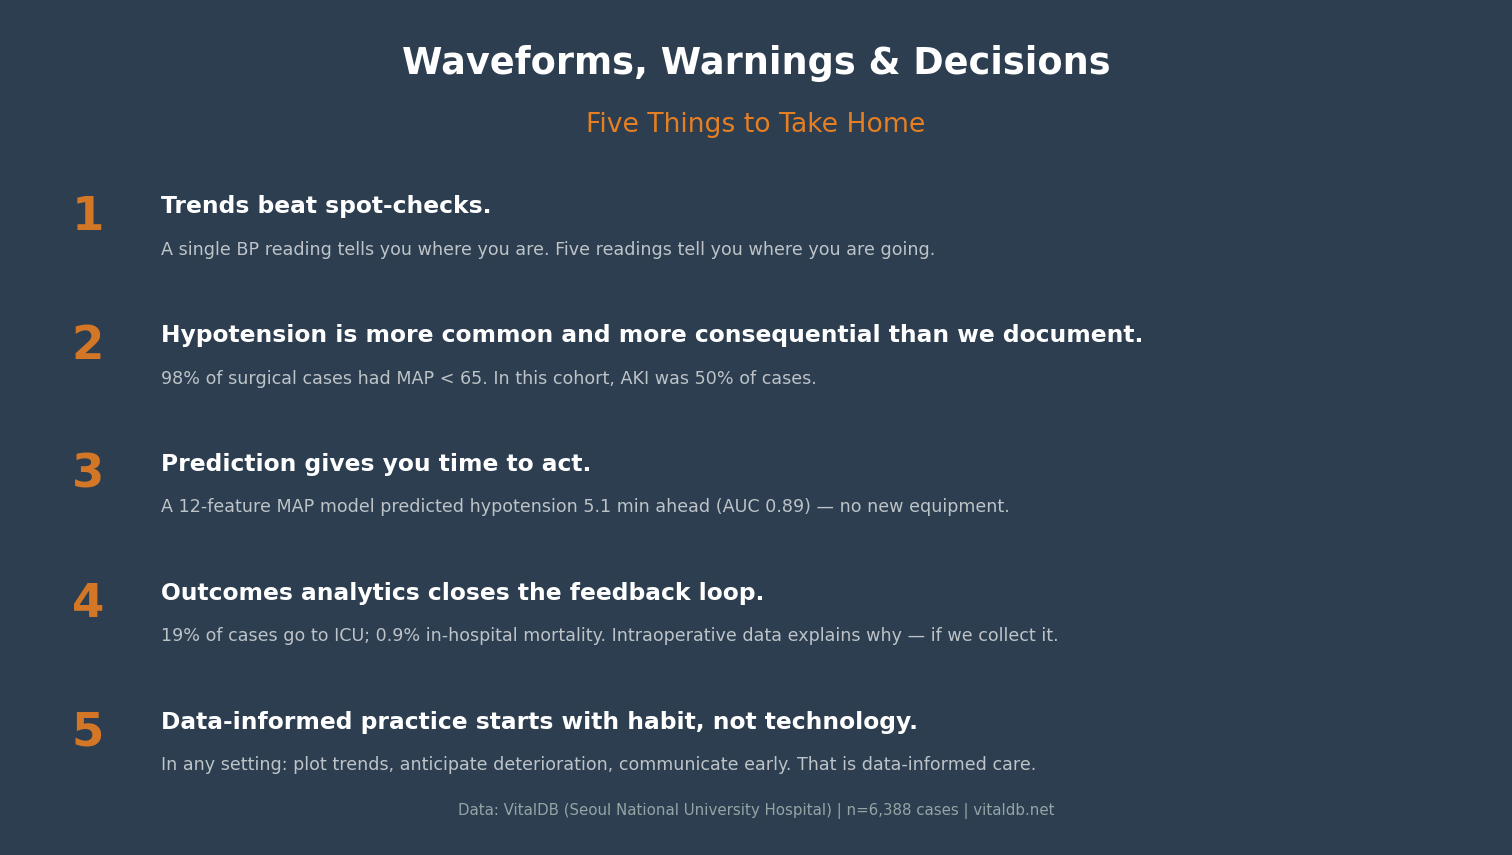


AFRICA STEMI LIVE! 2026 — Session Materials Complete
Figures saved to: /Volumes/iDrisAI/VitalDBGit/stemi_figures
  01_surveillance_gap.png  (185 KB)
  02_waveform_anatomy.png  (181 KB)
  03_silent_harm.png  (208 KB)
  04_prediction_model.png  (363 KB)
  05_simulation_cases.png  (729 KB)
  06_outcomes_analytics.png  (273 KB)
  07_africa_simulation.png  (350 KB)
  08_closing_takeaways.png  (85 KB)

Model performance:
  Random Forest AUC : 0.893
  Logistic Reg AUC  : 0.872
  Median lead time  : 5.1 min
  >= 2 min warning  : 67% of events

Registry stats:
  All-cases dataset : 6,388 cases
  ART cache cohort  : 100 cases  |  AKI: 50 / No-AKI: 50


In [16]:
# ── Closing Slide — Key Takeaways ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(SLATE)
ax.set_facecolor(SLATE)
ax.axis('off')

ax.text(0.5, 0.96, 'Waveforms, Warnings & Decisions',
        transform=ax.transAxes, ha='center', fontsize=22, fontweight='bold', color='white', va='top')
ax.text(0.5, 0.88, 'Five Things to Take Home',
        transform=ax.transAxes, ha='center', fontsize=16, color=AMBER, va='top')

icu_any_pct = 0
if icu_col and icu_col in cases.columns:
    icu_any_pct = 100 * (cases[icu_col].dropna() > 0).mean()

death_pct = 0
if death_col and death_col in cases.columns:
    death_pct = 100 * cases[death_col].mean()

hypo_prev = 100 * np.mean(art_wide.groupby('caseid')['mbp'].apply(lambda x: np.any(x < HYPO_THR)))
lead_time_med = np.median(lead_times) if lead_times else 5.0

takeaways = [
    ('1', 'Trends beat spot-checks.',
     'A single BP reading tells you where you are. Five readings tell you where you are going.'),
    ('2', 'Hypotension is more common and more consequential than we document.',
     f'{hypo_prev:.0f}% of surgical cases had MAP < 65. In this cohort, AKI was {100*lbl["aki_any"].mean():.0f}% of cases.'),
    ('3', 'Prediction gives you time to act.',
     f'A 12-feature MAP model predicted hypotension {lead_time_med:.1f} min ahead (AUC {rf_auc:.2f}) — no new equipment.'),
    ('4', 'Outcomes analytics closes the feedback loop.',
     f'{icu_any_pct:.0f}% of cases go to ICU; {death_pct:.1f}% in-hospital mortality. '
     f'Intraoperative data explains why — if we collect it.'),
    ('5', 'Data-informed practice starts with habit, not technology.',
     'In any setting: plot trends, anticipate deterioration, communicate early. That is data-informed care.'),
]

for i, (num, headline, detail) in enumerate(takeaways):
    y = 0.78 - i * 0.155
    ax.text(0.04, y, num, transform=ax.transAxes, fontsize=28, fontweight='bold',
            color=AMBER, va='top', alpha=0.9)
    ax.text(0.10, y, headline, transform=ax.transAxes, fontsize=14,
            fontweight='bold', color='white', va='top')
    ax.text(0.10, y - 0.055, detail, transform=ax.transAxes, fontsize=10.5,
            color='#BDC3C7', va='top')

ax.text(0.5, 0.03,
        'Data: VitalDB (Seoul National University Hospital) | n=6,388 cases | vitaldb.net',
        transform=ax.transAxes, ha='center', fontsize=9, color='#95A5A6', va='bottom')

save_fig('08_closing_takeaways')
plt.show()

print('\n' + '='*60)
print('AFRICA STEMI LIVE! 2026 — Session Materials Complete')
print('='*60)
print(f'Figures saved to: {FIG_DIR}')
for p in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p.name}  ({p.stat().st_size//1024} KB)')
print()
print('Model performance:')
print(f'  Random Forest AUC : {rf_auc:.3f}')
print(f'  Logistic Reg AUC  : {lr_auc:.3f}')
if lead_times:
    print(f'  Median lead time  : {np.median(lead_times):.1f} min')
    print(f'  >= 2 min warning  : {100*np.mean(np.array(lead_times)>=2):.0f}% of events')
print()
print('Registry stats:')
print(f'  All-cases dataset : {len(cases):,} cases')
print(f'  ART cache cohort  : {len(lbl)} cases  |  AKI: {int(lbl["aki_any"].sum())} / No-AKI: {int((lbl["aki_any"]==0).sum())}')

### Chapter summary

Let us recap the journey we have taken:

1. **The surveillance gap is real and dangerous.** Intermittent blood pressure monitoring misses the majority of hypotensive episodes. Continuous monitoring — even if only by increasing the frequency of non-invasive measurements — dramatically improves our ability to detect and treat low blood pressure.

2. **Hypotension burden is dose-dependent.** There is no clearly safe threshold of low blood pressure. Every minute below MAP 65 mmHg incrementally increases the risk of postoperative organ injury, particularly acute kidney injury.

3. **Prediction is possible with existing data.** Using nothing more than 10 minutes of blood pressure trend data, a machine learning model can provide clinically useful advance warning of impending hypotension. These tools are not replacements for clinical judgement — they are augmentations.

4. **Intraoperative haemodynamics predict postoperative outcomes.** What happens during surgery does not stay in surgery. Hypotension burden, vasopressor requirements, and haemodynamic variability are all associated with ICU admission, AKI, and other complications.

5. **Trends beat snapshots at every resource level.** Whether you have a manual blood pressure cuff or a full arterial line with real-time analytics, the single most important change you can make is to **look at the trajectory of the blood pressure, not just the latest number**.

The data in this chapter come from one registry (VitalDB), but the principles are universal. Every patient under your care generates data. The question is whether you use it.

---

*This chapter uses data from the VitalDB open dataset (Seoul National University Hospital). For details on the dataset and how to access it, see Chapter 1.1 and Appendix C.*